# Detecting Unlicensed Commercial Short-Term Rental Operators in Las Vegas

**A multimodal Positive-Unlabeled (PU) learning system for Clark County STR enforcement triage.**

---

## ⚠️ Read this first — what this model does and does not claim

This notebook produces a **risk score**, not a legal finding. Every output should be read as:

> *"This listing's observable behavior resembles that of a commercial hospitality operation."*

It must **never** be read as:

> ~~"This host is operating illegally."~~

Concretely, the scores here **cannot** distinguish:

- A host who is genuinely exempt (bona-fide 31+ night residential leases, licensed condo-hotel
  inventory operating under a property-wide permit) from one using "Exempt" to evade registration.
- A listing whose license simply is not recorded in this public snapshot from one that has none.
- An owner with several properties held for family use from a commercial portfolio.

The intended use is **triage**: ordering a queue so that a county office with capacity to audit,
say, 200 properties per quarter spends that capacity where the behavioral evidence is strongest.
A high score is a reason to **look**, and nothing more. Section 9 lists the specific failure modes,
fairness concerns, and the human-review controls that must wrap any deployment.

---

## The problem

Clark County requires short-term rentals to hold a license. In this snapshot of 20,296 listings:

| License field | Listings | Interpretation |
|---|---:|---|
| Real license number (`G##-#####`) | 684 | Confirmed permitted operators |
| `"Exempt"` | 6,009 | **Ambiguous** — genuine exemption *or* evasion |
| Null / blank | 13,209 | No license information at all |
| Other free-text (`STR-…`, state biz IDs) | 384 | Licensed under a *different* scheme (see §3.2) |

Meanwhile **34.7% of all listings belong to hosts operating 20+ properties**. These are not
homeowners renting a spare room — they are unregistered hospitality businesses at scale.

We only ever observe *confirmed positives* (a real license number) and a large *unlabeled* pool.
We never observe a confirmed negative: no listing is stamped "verified unlicensed." That is
exactly the setting **Positive-Unlabeled learning** was built for, and it drives the modeling
choices in §3 and §5.

---

## Notebook roadmap

| § | Contents |
|---|---|
| 0 | Environment, seeds, reproducibility, data load |
| 1 | Exploratory data analysis with visualizations |
| 2 | Cleaning (documented, conservative) |
| 3 | PU label construction + **a critical diagnostic that reframes the target** |
| 4 | Feature engineering (behavioral, spatial, textual) |
| 5 | Multimodal nnPU network in PyTorch — loss derived, unit-tested, prior sensitivity |
| 6 | Optuna hyperparameter search (30 trials) |
| 7 | Baselines: LightGBM (tabular-only) and a deep autoencoder |
| 8 | Evaluation: AUC, precision@k, calibration, face validity, ablation |
| 9 | The deployable enforcement score, limitations, and ethics |

---
# §0 — Environment & Reproducibility

The first cell installs everything needed on a bare Google Colab runtime and is a no-op on a
machine that already has the packages. Keep it first so the notebook runs top-to-bottom on
Colab free GPU without edits.

In [1]:
# ── Cell 1: dependencies (Colab-safe, idempotent) ────────────────────────────
import importlib, subprocess, sys

# (import name, pip spec). Only missing packages are installed.
REQUIREMENTS = [
    ("numpy",                 "numpy"),
    ("pandas",                "pandas"),
    ("sklearn",               "scikit-learn"),
    ("scipy",                 "scipy"),
    ("matplotlib",            "matplotlib"),
    ("torch",                 "torch"),
    ("sentence_transformers", "sentence-transformers"),
    ("optuna",                "optuna"),
    ("lightgbm",              "lightgbm"),
]

missing = []
for mod, pkg in REQUIREMENTS:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    print("Done. (On Colab you may need Runtime > Restart session if torch was reinstalled.)")
else:
    print("All dependencies already present.")

/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies already present.


In [2]:
# ── Cell 2: imports, global seeds, device ────────────────────────────────────
import os, sys, re, json, math, random, warnings, time

# macOS only, and it must happen BEFORE torch or LightGBM is imported. Both ship
# their own OpenMP runtime; on Darwin the two thread pools collide and hard-crash
# the interpreter (SIGSEGV) as soon as LightGBM trains in a process that has already
# used torch — which is exactly what §7 does. Capping OpenMP to a single thread is
# the only mitigation that held under test. Linux (Colab) is unaffected and keeps
# full parallelism, and everything here runs on GPU anyway, so the cost is nil.
if sys.platform == "darwin":
    os.environ.setdefault("OMP_NUM_THREADS", "1")

from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# LightGBM is imported BEFORE torch on purpose. Both link an OpenMP runtime, and on
# macOS loading torch's copy first makes LightGBM segfault the interpreter when it
# trains (§7). Importing it first is a free fix and is a no-op on Colab/Linux.
import lightgbm as lgb
import optuna

import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import expit          # numerically stable sigmoid

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

# ── Reproducibility ──────────────────────────────────────────────────────────
# A single seed drives Python, NumPy and Torch. Every stochastic step downstream
# (splits, weight init, dropout, Optuna sampling, LightGBM subsampling) either
# consumes this seed or is given an explicit derived seed, so a fresh top-to-bottom
# run reproduces every number in this notebook.
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed every RNG this notebook touches."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Deterministic cuDNN. Costs a little throughput; buys identical reruns, which
# matters far more for a notebook whose job is to be audited.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
# Prefer CUDA (Colab), then Apple MPS, then CPU. Everything here fits comfortably
# in free-tier GPU memory; the whole notebook also runs on CPU in a few minutes.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

IN_COLAB = "google.colab" in sys.modules

print(f"torch  {torch.__version__}")
print(f"device {DEVICE}")
print(f"colab  {IN_COLAB}")
print(f"seed   {SEED}")

torch  2.13.0
device mps
colab  False
seed   42


### Visual style

All figures share one small design system so the notebook reads as a single document:

- **Categorical hues** are assigned in a fixed order and never cycled — a series keeps its colour
  even when a filter removes its neighbours. The four-slot order below was validated for
  colour-vision-deficiency separation (worst adjacent ΔE 9.1 in OKLab×100, against a floor of 8).
- **Magnitude** (host portfolio size) uses a single-hue light→dark ordinal ramp, never a rainbow.
- Marks are thin, gridlines are hairline and recessive, and any series whose fill sits below 3:1
  contrast on the page carries a direct value label so colour is never the only channel.

In [3]:
# ── Cell 3: plotting theme ───────────────────────────────────────────────────
# Fixed categorical slots. Assign by entity, never by rank, and never cycle past
# the list — an extra category folds into "Other" instead of inventing a hue.
CAT = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
CAT_ORDER = [CAT["blue"], CAT["orange"], CAT["aqua"], CAT["yellow"]]

# Single-hue ordinal ramp for ordered magnitude (host portfolio size bins).
# Light end clears the surface at 2.06:1; lightness is monotone with even steps.
SEQ4 = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]

INK        = "#0b0b0b"   # primary text
INK_SOFT   = "#52514e"   # secondary text
GRID       = "#e6e5e1"   # hairline grid, one shade off the surface
SURFACE    = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi":        110,
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "semibold",
    "axes.titlelocation":"left",
    "axes.titlepad":     10,
    "axes.labelsize":    10,
    "axes.labelcolor":   INK_SOFT,
    "axes.edgecolor":    GRID,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "grid.linestyle":    "-",      # never dashed: dashing reads as "projection"
    "xtick.color":       INK_SOFT,
    "ytick.color":       INK_SOFT,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "lines.linewidth":   2.0,      # thin marks
    "lines.markersize":  5,
    "text.color":        INK,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    """Apply the shared chrome: recessive spines, one grid direction, left title."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(ygrid, axis="y")
    ax.grid(xgrid, axis="x")
    if title:  ax.set_title(title, color=INK)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

print("Plot theme ready.")

Plot theme ready.


In [4]:
# ── Cell 4: locate and load the dataset ──────────────────────────────────────
# Search a few conventional locations so the notebook runs unchanged locally and
# on Colab (where the file is usually uploaded to /content or mounted from Drive).
CANDIDATE_PATHS = [
    Path("airbnb_listings.csv"),
    Path("./data/airbnb_listings.csv"),
    Path("/content/airbnb_listings.csv"),
    Path("/content/drive/MyDrive/airbnb_listings.csv"),
    Path.home() / "Downloads" / "airbnb_listings.csv",
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)

if DATA_PATH is None and IN_COLAB:
    from google.colab import files          # prompt for an upload on Colab
    print("airbnb_listings.csv not found — please upload it.")
    up = files.upload()
    DATA_PATH = Path(next(iter(up)))

if DATA_PATH is None:
    raise FileNotFoundError(
        "airbnb_listings.csv not found. Place it beside this notebook, "
        f"or add its location to CANDIDATE_PATHS. Searched: {[str(p) for p in CANDIDATE_PATHS]}"
    )

raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}  →  {raw.shape[0]:,} rows x {raw.shape[1]} columns")

# Integrity assertions: if the snapshot is ever swapped, fail loudly here rather
# than silently producing different numbers 40 cells later.
assert raw["id"].is_unique,            "listing id is not unique"
assert not raw.duplicated().any(),     "duplicate rows present"

ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)   # embeddings cache, figures
raw.head()

Loaded airbnb_listings.csv  →  20,296 rows x 19 columns


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,44701,"CES Jan3-10, 2027, 3 bed,2 baths, 1020sqft, Sl...",189245.0,1.462512e+18,Christine,NaN,Unincorporated Areas,36.11689,-115.16263,Entire home/apt,243.0,7.0,4,2024-01-14,0.03,1.0,15,0,Exempt
1,113019,MGM Signature Studio !,575684.0,1.462513e+18,James,NaN,Unincorporated Areas,36.10905,-115.16641,Entire home/apt,NaN,2.0,203,2025-04-14,1.14,6.0,0,0,Exempt
2,114140,MGM Signature 1BR/2BA Suite W/ View,575684.0,1.462513e+18,James,NaN,Unincorporated Areas,36.10736,-115.16591,Entire home/apt,142.0,2.0,164,2025-09-15,0.97,6.0,51,3,Exempt
3,133084,"Beautiful, Sleek, Sexy Condo - Long Term Rental",653641.0,1.462525e+18,Brent,NaN,City of Las Vegas,36.16085,-115.14704,Entire home/apt,87.0,30.0,2,2017-09-09,0.01,1.0,300,0,NaN
4,143096,"Las Vegas House with Private Pool 2,000 sq ft",694506.0,1.462526e+18,Shari,NaN,Unincorporated Areas,36.05150,-115.22566,Entire home/apt,232.0,3.0,281,2026-05-31,1.54,1.0,313,28,NaN


In [5]:
# Column types and a first look at what each field actually contains.
schema = pd.DataFrame({
    "dtype":     raw.dtypes.astype(str),
    "non_null":  raw.notna().sum(),
    "null_pct":  (raw.isna().mean() * 100).round(2),
    "n_unique":  raw.nunique(),
    "example":   [raw[c].dropna().iloc[0] if raw[c].notna().any() else None for c in raw.columns],
})
schema

,dtype,non_null,null_pct,n_unique,example
id,int64,20296,0.00,20296,44701
name,str,20296,0.00,17760,"CES Jan3-10, 2027, 3 bed,2 baths, 1020sqft, Sl..."
host_id,float64,20234,0.31,6797,189245.0
host_profile_id,float64,20167,0.64,6783,1462512160597784832.0
host_name,str,20168,0.63,3697,Christine
neighbourhood_group,float64,0,100.00,0,None
neighbourhood,str,20296,0.00,7,Unincorporated Areas
latitude,float64,20296,0.00,13159,36.11689
longitude,float64,20296,0.00,13693,-115.16263
room_type,str,20296,0.00,4,Entire home/apt


---
# §1 — Exploratory Data Analysis

The goal of this section is not a tour of the data; it is to establish four specific facts that
determine the modelling decisions in §2–§5:

1. `price` and `minimum_nights` are severely right-skewed with implausible extremes → they need a
   transform and a cap, not raw use (§2).
2. Listing ownership is extremely concentrated → host portfolio size is the single strongest
   behavioral signal available (§4).
3. License status is **not** distributed the way the business problem assumes → this reframes the
   entire target (§3.3). This is the most consequential finding in the notebook.
4. Missingness is informative, not random → missingness gets its own indicator features (§2).

## 1.1 Missingness

Two of these columns are missing in a way that carries meaning rather than noise:

- `reviews_per_month` / `last_review` are null on exactly the same 28.3% of rows — those are
  listings that have **never been reviewed**. That is a fact about the listing, not an absent
  measurement, so it becomes a flag (§2).
- `price` is missing on 14.6% of rows. Airbnb suppresses the nightly rate for listings whose
  pricing depends on stay length or that are unavailable — again structural, not random. We
  therefore **do not impute it** (§2).
- `neighbourhood_group` is 100% null and is dropped outright.

In [6]:
# Missingness table, ordered by severity, annotated with what the gap means.
NULL_MEANING = {
    "neighbourhood_group":            "Entirely empty in this snapshot — dropped in §2.",
    "license":                        "No license recorded. Ambiguous: unlicensed OR simply not published.",
    "last_review":                    "Never reviewed (identical mask to reviews_per_month).",
    "reviews_per_month":              "Never reviewed → becomes 0 + never_reviewed flag.",
    "price":                          "Rate suppressed/unavailable. NOT imputed — flagged instead.",
    "host_profile_id":                "Host profile not resolvable; not used as a feature.",
    "host_name":                      "Not used as a feature (PII, and no signal beyond host_id).",
    "host_id":                        "Rare; row still usable via calculated_host_listings_count.",
    "calculated_host_listings_count": "Rare; imputed to 1 (a lone listing) in §2.",
    "minimum_nights":                 "7 rows; imputed to the median in §2.",
}

miss = (pd.DataFrame({
            "n_missing": raw.isna().sum(),
            "pct_missing": (raw.isna().mean() * 100).round(2)})
        .query("n_missing > 0")
        .sort_values("pct_missing", ascending=False))
miss["meaning"] = miss.index.map(NULL_MEANING).fillna("—")

# Confirm the never-reviewed pair really is one mask, not two coincidences.
same_mask = (raw["last_review"].isna() == raw["reviews_per_month"].isna()).all()
print(f"last_review and reviews_per_month share an identical null mask: {same_mask}")
miss

last_review and reviews_per_month share an identical null mask: True


,n_missing,pct_missing,meaning
neighbourhood_group,20296,100.00,Entirely empty in this snapshot — dropped in §2.
license,13209,65.08,No license recorded. Ambiguous: unlicensed OR ...
last_review,5745,28.31,Never reviewed (identical mask to reviews_per_...
reviews_per_month,5745,28.31,Never reviewed → becomes 0 + never_reviewed flag.
price,2965,14.61,Rate suppressed/unavailable. NOT imputed — fla...
host_profile_id,129,0.64,Host profile not resolvable; not used as a fea...
host_name,128,0.63,"Not used as a feature (PII, and no signal beyo..."
host_id,62,0.31,Rare; row still usable via calculated_host_lis...
calculated_host_listings_count,62,0.31,Rare; imputed to 1 (a lone listing) in §2.
minimum_nights,7,0.03,7 rows; imputed to the median in §2.


## 1.2 Price and minimum-nights distributions

Both variables are pathological in the raw scale and need explicit handling.

findfont: Failed to find font weight semibold, now using 700.


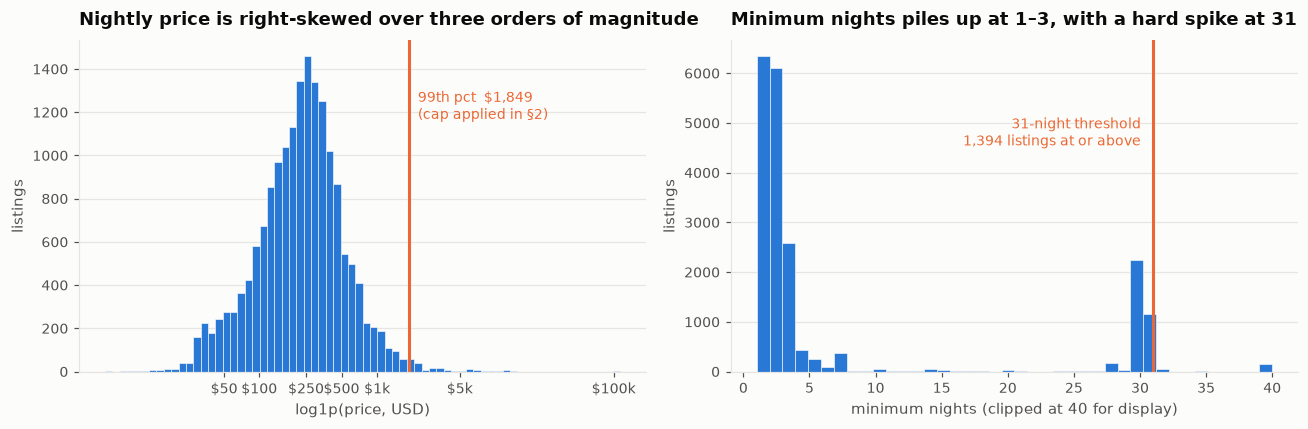

           price  minimum_nights
count   17331.00        20289.00
mean      334.35            8.40
std      1004.55           18.26
min         4.00            1.00
25%       133.00            1.00
50%       234.00            2.00
75%       370.00            4.00
95%       856.00           31.00
99%      1849.40           32.00
max    114164.00          365.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))

# ── Left: price, log scale ───────────────────────────────────────────────────
# One series → one colour (slot 1) and no legend; the title names the series.
price = raw["price"].dropna()
p99   = price.quantile(0.99)

axes[0].hist(np.log1p(price), bins=70, color=CAT["blue"], edgecolor=SURFACE, linewidth=0.4)
axes[0].axvline(np.log1p(p99), color=CAT["orange"], linewidth=2.0)
axes[0].annotate(f"99th pct  ${p99:,.0f}\n(cap applied in §2)",
                 xy=(np.log1p(p99), axes[0].get_ylim()[1] * 0.80),
                 xytext=(6, 0), textcoords="offset points",
                 fontsize=9, color=CAT["orange"], va="center")
style_ax(axes[0], "Nightly price is right-skewed over three orders of magnitude",
         "log1p(price, USD)", "listings")

# Ticks labelled in dollars so the log axis stays readable.
ticks = [50, 100, 250, 500, 1000, 5000, 100000]
axes[0].set_xticks(np.log1p(ticks))
axes[0].set_xticklabels([f"${t:,}" if t < 1000 else f"${t//1000:,}k" for t in ticks])

# ── Right: minimum nights, capped view ───────────────────────────────────────
mn = raw["minimum_nights"].dropna()
axes[1].hist(mn.clip(upper=40), bins=40, color=CAT["blue"], edgecolor=SURFACE, linewidth=0.4)
axes[1].axvline(31, color=CAT["orange"], linewidth=2.0)
axes[1].annotate(f"31-night threshold\n{(mn >= 31).sum():,} listings at or above",
                 xy=(31, axes[1].get_ylim()[1] * 0.72), xytext=(-8, 0),
                 textcoords="offset points", fontsize=9, color=CAT["orange"],
                 va="center", ha="right")
style_ax(axes[1], "Minimum nights piles up at 1–3, with a hard spike at 31",
         "minimum nights (clipped at 40 for display)", "listings")

plt.tight_layout(); plt.show()

desc = pd.DataFrame({
    "price":          price.describe(percentiles=[.25, .5, .75, .95, .99]),
    "minimum_nights": mn.describe(percentiles=[.25, .5, .75, .95, .99]),
}).round(2)
print(desc.to_string())

**What this justifies (implemented in §2):**

| Observation | Decision |
|---|---|
| `price` spans \$4 → \$114,164; the 99th pct is \$1,849 | `log1p` to make the scale additive, then cap at p99. The max is 62× the 99th percentile — almost certainly a data-entry artifact or a listing priced to be unbookable. Left uncapped, a handful of rows would dominate the standardised feature. |
| `price` missing on 14.6% | Do **not** impute — a suppressed rate is itself a signal. Fill with the median *after* logging purely so the tensor is finite, and add `price_missing` so the network can learn to discount that value entirely. |
| `minimum_nights` has a hard spike at exactly 31, max 365 | The 31-night spike is the legal artifact at the heart of this problem: Clark County's STR rules bite below 31 nights, so setting `minimum_nights = 31` is the standard way to claim exemption. It gets a dedicated binary feature (`is_31plus`), and the raw column is capped at p99 (32) since values above that carry no extra information. |

## 1.3 Host concentration

The business framing claims one-third of listings belong to large operators. This chart quantifies
exactly how concentrated ownership is — and it is more extreme than a Gini-style summary suggests.

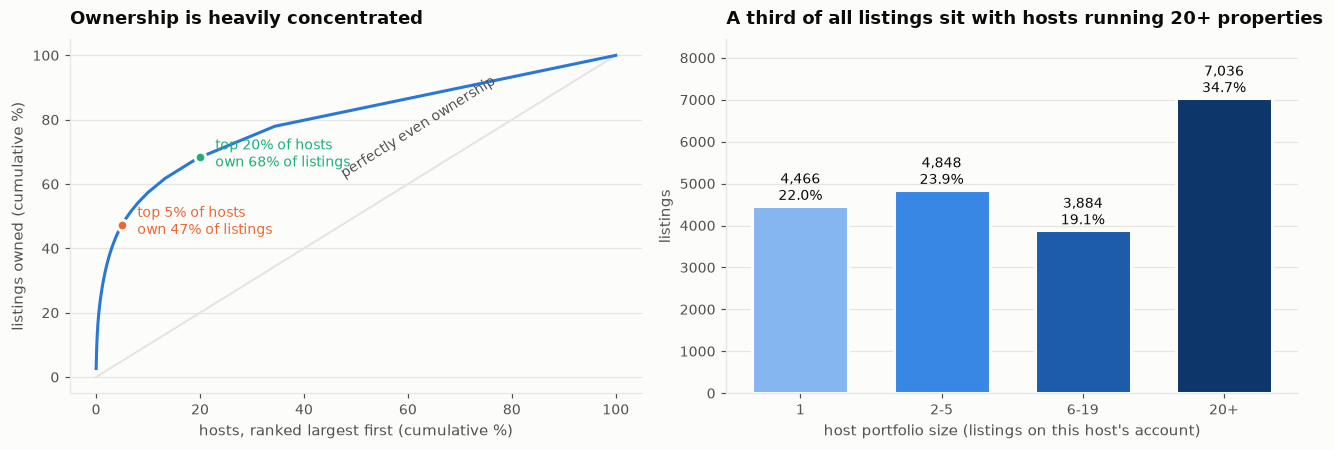

unique hosts                    : 6,797
largest single portfolio        : 537 listings
listings held by 20+ hosts      : 7,036 (34.7%)
median host portfolio size      : 1


In [8]:
# Cumulative share of listings against hosts ranked by portfolio size.
host_sizes = (raw.dropna(subset=["host_id"])
                 .groupby("host_id").size()
                 .sort_values(ascending=False))

cum_listings = host_sizes.cumsum() / host_sizes.sum()
cum_hosts    = np.arange(1, len(host_sizes) + 1) / len(host_sizes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Left: concentration curve ────────────────────────────────────────────────
axes[0].plot(cum_hosts * 100, cum_listings * 100, color=CAT["blue"])
axes[0].plot([0, 100], [0, 100], color=GRID, linewidth=1.4, zorder=1)   # equal-ownership line
axes[0].annotate("perfectly even ownership", xy=(62, 62), fontsize=9,
                 color=INK_SOFT, rotation=32, ha="center")

# Direct-label the two numbers the reader should take away, rather than every point.
for frac, colr in ((0.05, CAT["orange"]), (0.20, CAT["aqua"])):
    k     = max(int(len(host_sizes) * frac), 1)
    share = cum_listings.iloc[k - 1] * 100
    axes[0].plot([frac * 100], [share], "o", color=colr, markersize=7,
                 markeredgecolor=SURFACE, markeredgewidth=2)
    axes[0].annotate(f"top {frac:.0%} of hosts\nown {share:.0f}% of listings",
                     xy=(frac * 100, share), xytext=(10, -6), textcoords="offset points",
                     fontsize=9, color=colr)
style_ax(axes[0], "Ownership is heavily concentrated",
         "hosts, ranked largest first (cumulative %)", "listings owned (cumulative %)")

# ── Right: listings by host-portfolio-size bin ───────────────────────────────
# Ordered bins → the ordinal ramp, not categorical hues.
BIN_EDGES  = [0, 1, 5, 19, np.inf]
BIN_LABELS = ["1", "2-5", "6-19", "20+"]
size_bin   = pd.cut(raw["calculated_host_listings_count"], BIN_EDGES, labels=BIN_LABELS)
by_bin     = size_bin.value_counts().reindex(BIN_LABELS)

bars = axes[1].bar(BIN_LABELS, by_bin.values, color=SEQ4, width=0.68,
                   edgecolor=SURFACE, linewidth=2)   # 2px surface gap between fills
# Direct labels: several ramp steps sit below 3:1 contrast, so the value must be legible without colour.
for b, v in zip(bars, by_bin.values):
    axes[1].annotate(f"{v:,}\n{v / len(raw):.1%}", xy=(b.get_x() + b.get_width() / 2, v),
                     xytext=(0, 4), textcoords="offset points",
                     ha="center", fontsize=9, color=INK)
axes[1].set_ylim(0, by_bin.max() * 1.20)
style_ax(axes[1], "A third of all listings sit with hosts running 20+ properties",
         "host portfolio size (listings on this host's account)", "listings")

plt.tight_layout(); plt.show()

print(f"unique hosts                    : {len(host_sizes):,}")
print(f"largest single portfolio        : {host_sizes.max():,} listings")
print(f"listings held by 20+ hosts      : {(raw['calculated_host_listings_count'] >= 20).sum():,} "
      f"({(raw['calculated_host_listings_count'] >= 20).mean():.1%})")
print(f"median host portfolio size      : {host_sizes.median():.0f}")

The curve sits far above the diagonal: a small minority of accounts hold the majority of inventory.
`calculated_host_listings_count` is therefore the most informative single column in the file, and it
is the backbone of the behavioral features in §4.

## 1.4 License status × host size — the finding that reframes the project

This is the crossing the business framing assumes will show large operators avoiding licenses.
It shows something considerably more interesting.

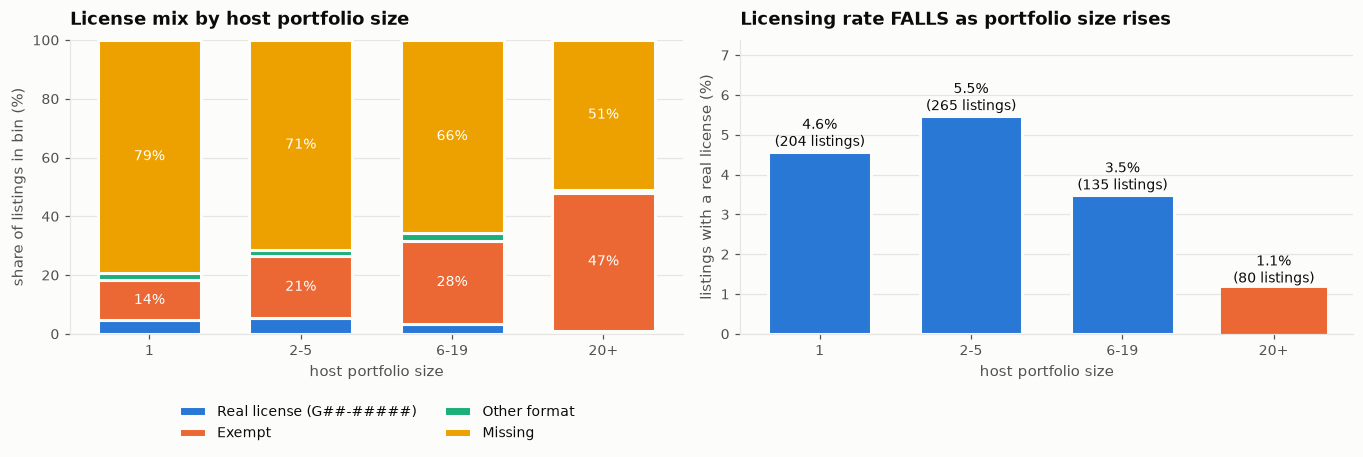

Counts:
 _lic_state  Real license (G##-#####)  Exempt  Other format  Missing
_size_bin                                                          
1                                204     612           106     3544
2-5                              265    1012           108     3463
6-19                             135    1092           106     2551
20+                               80    3293            74     3589 

Row-normalised (%):
 _lic_state  Real license (G##-#####)  Exempt  Other format  Missing
_size_bin                                                          
1                                4.6    13.7           2.4     79.4
2-5                              5.5    20.9           2.2     71.4
6-19                             3.5    28.1           2.7     65.7
20+                              1.1    46.8           1.1     51.0


In [9]:
# Four mutually exclusive license states. The "other format" bucket is not in the
# original data profile — it is surfaced here because it materially affects §3.
LICENSE_RE = re.compile(r"^G\d{2}-\d{5}")

def license_state(v) -> str:
    if pd.isna(v):                    return "Missing"
    v = str(v).strip()
    if v == "Exempt":                 return "Exempt"
    if LICENSE_RE.match(v):           return "Real license (G##-#####)"
    return "Other format"

raw["_lic_state"] = raw["license"].map(license_state)
LIC_STATES = ["Real license (G##-#####)", "Exempt", "Other format", "Missing"]
LIC_COLORS = dict(zip(LIC_STATES, CAT_ORDER))   # fixed slot per entity, never by rank

raw["_size_bin"] = pd.cut(raw["calculated_host_listings_count"], BIN_EDGES, labels=BIN_LABELS)

ct     = pd.crosstab(raw["_size_bin"], raw["_lic_state"]).reindex(columns=LIC_STATES).fillna(0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# ── Left: composition within each host-size bin ──────────────────────────────
bottom = np.zeros(len(ct_pct))
for state in LIC_STATES:
    vals = ct_pct[state].values
    axes[0].bar(BIN_LABELS, vals, bottom=bottom, label=state, color=LIC_COLORS[state],
                width=0.68, edgecolor=SURFACE, linewidth=2)   # 2px surface gap
    # Direct-label only segments with room, so nothing is clipped.
    for x, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 6:
            axes[0].annotate(f"{v:.0f}%", xy=(x, b + v / 2), ha="center", va="center",
                             fontsize=9, color="white" if state != "Other format" else INK)
    bottom += vals
axes[0].set_ylim(0, 100)
style_ax(axes[0], "License mix by host portfolio size",
         "host portfolio size", "share of listings in bin (%)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2)

# ── Right: the licensing rate alone — the story is one number per bin ────────
lic_rate = ct_pct["Real license (G##-#####)"]
bars = axes[1].bar(BIN_LABELS, lic_rate.values, color=CAT["blue"], width=0.68,
                   edgecolor=SURFACE, linewidth=2)
bars[-1].set_color(CAT["orange"])          # emphasis: highlight one, recede the rest
for b, v, n in zip(bars, lic_rate.values, ct["Real license (G##-#####)"].values):
    axes[1].annotate(f"{v:.1f}%\n({int(n)} listings)",
                     xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 4),
                     textcoords="offset points", ha="center", fontsize=9, color=INK)
axes[1].set_ylim(0, lic_rate.max() * 1.35)
style_ax(axes[1], "Licensing rate FALLS as portfolio size rises",
         "host portfolio size", "listings with a real license (%)")

plt.tight_layout(); plt.show()

print("Counts:\n", ct.to_string(), "\n")
print("Row-normalised (%):\n", ct_pct.round(1).to_string())

### 🔴 Read the right-hand panel carefully

| Host portfolio | Listings | With a real `G##-#####` license | Rate |
|---|---:|---:|---:|
| 1 property | 4,466 | 204 | **4.6%** |
| 2–5 | 4,848 | 265 | 5.5% |
| 6–19 | 3,884 | 135 | 3.5% |
| 20+ | 7,036 | 80 | **1.1%** |

The licensing rate among the largest operators is **roughly a quarter** that of single-property
hosts. And look at where the large operators go instead: **47% of listings held by 20+ hosts are
marked `"Exempt"`**, versus 14% among single-property hosts.

This is a genuinely important result, and it breaks a naive reading of the project brief. A model
trained to recognise "looks like a licensed listing" learns the profile of a **small residential
owner-operator who went through the county's permit process** — the opposite of the enforcement
target. Ranking unlicensed listings by that score would send auditors to spare-bedroom hosts while
537-property operators sit at the bottom of the queue.

§3.3 confronts this directly and §9 builds the score that actually ships. The nnPU model is still
worth building — "similarity to a permitted residential STR" is a real, learnable, useful quantity —
but its output is one **factor** in an enforcement score, not the score itself.

## 1.5 Spatial structure

findfont: Failed to find font weight semibold, now using 700.


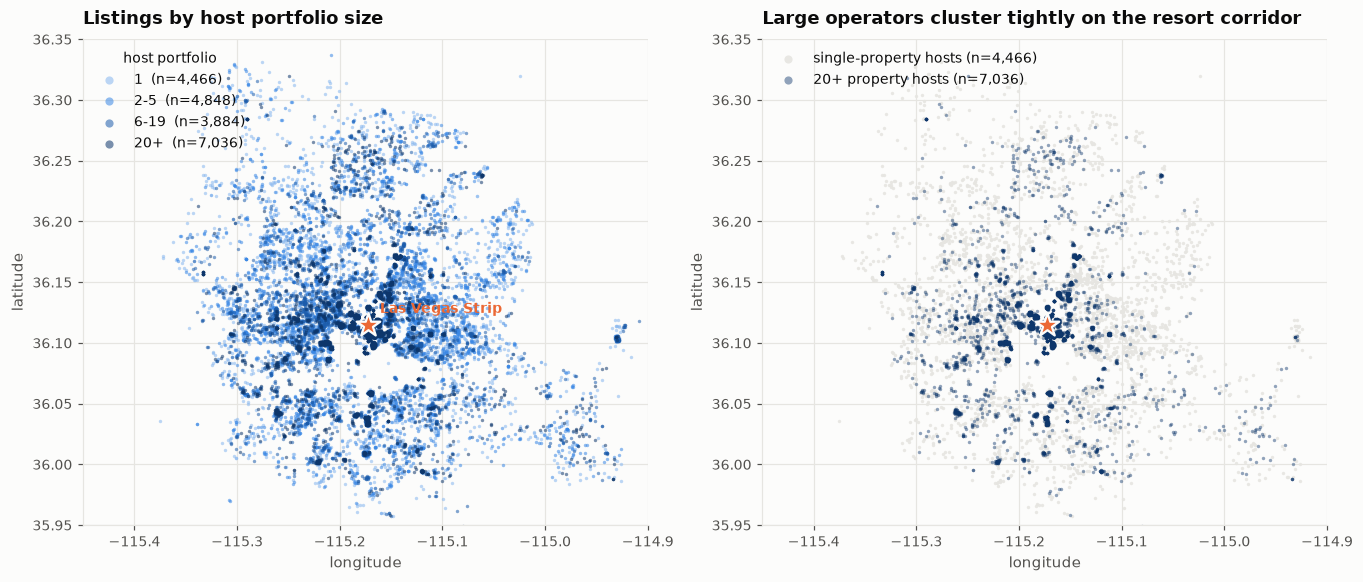

Median km to the Strip, by host portfolio size:
_size_bin
1       8.30
2-5     7.40
6-19    5.00
20+     1.75

Share of listings within 2 km of the Strip, by host portfolio size:
_size_bin
1       10.4
2-5     15.2
6-19    30.2
20+     55.5


In [10]:
# Where do large operators cluster? Portfolio size is an ordered magnitude, so it
# gets the single-hue ordinal ramp with a scale legend — never categorical hues.
STRIP_LAT, STRIP_LON = 36.1147, -115.1728

geo = raw.dropna(subset=["latitude", "longitude", "_size_bin"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))

# ── Left: all listings, coloured by portfolio-size bin ───────────────────────
# Drawn smallest-bin-first so the large operators (dark, the story) land on top.
for label, colr in zip(BIN_LABELS, SEQ4):
    sub = geo[geo["_size_bin"] == label]
    axes[0].scatter(sub["longitude"], sub["latitude"], s=5, c=colr, alpha=0.55,
                    linewidths=0, label=f"{label}  (n={len(sub):,})")
axes[0].scatter([STRIP_LON], [STRIP_LAT], marker="*", s=260, c=CAT["orange"],
                edgecolors=SURFACE, linewidths=1.5, zorder=5)
axes[0].annotate("Las Vegas Strip", xy=(STRIP_LON, STRIP_LAT), xytext=(8, 8),
                 textcoords="offset points", fontsize=9, color=CAT["orange"], weight="semibold")
axes[0].set_xlim(-115.45, -114.90); axes[0].set_ylim(35.95, 36.35)
style_ax(axes[0], "Listings by host portfolio size", "longitude", "latitude", xgrid=True)
leg = axes[0].legend(title="host portfolio", loc="upper left", markerscale=2.4)
leg.get_title().set_fontsize(9)

# ── Right: where 20+ operators concentrate, as a density contrast ────────────
big   = geo[geo["_size_bin"] == "20+"]
small = geo[geo["_size_bin"] == "1"]
axes[1].scatter(small["longitude"], small["latitude"], s=5, c=GRID, alpha=0.9,
                linewidths=0, label=f"single-property hosts (n={len(small):,})")
axes[1].scatter(big["longitude"], big["latitude"], s=5, c=SEQ4[-1], alpha=0.45,
                linewidths=0, label=f"20+ property hosts (n={len(big):,})")
axes[1].scatter([STRIP_LON], [STRIP_LAT], marker="*", s=260, c=CAT["orange"],
                edgecolors=SURFACE, linewidths=1.5, zorder=5)
axes[1].set_xlim(-115.45, -114.90); axes[1].set_ylim(35.95, 36.35)
style_ax(axes[1], "Large operators cluster tightly on the resort corridor",
         "longitude", "latitude", xgrid=True)
axes[1].legend(loc="upper left", markerscale=2.4)

plt.tight_layout(); plt.show()

def haversine_km(lat, lon, lat0=STRIP_LAT, lon0=STRIP_LON):
    """Great-circle distance in km from each (lat, lon) to a reference point."""
    R = 6371.0088
    p1, p2 = np.radians(lat), np.radians(lon)
    q1, q2 = math.radians(lat0), math.radians(lon0)
    a = np.sin((p1 - q1) / 2) ** 2 + np.cos(q1) * np.cos(p1) * np.sin((p2 - q2) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

geo["_dist"] = haversine_km(geo["latitude"].values, geo["longitude"].values)
print("Median km to the Strip, by host portfolio size:")
print(geo.groupby("_size_bin", observed=True)["_dist"].median().round(2).to_string())
print("\nShare of listings within 2 km of the Strip, by host portfolio size:")
print((geo.assign(near=geo["_dist"] < 2)
          .groupby("_size_bin", observed=True)["near"].mean().mul(100).round(1)).to_string())

Large operators sit dramatically closer to the resort corridor — the median 20+ host listing is a
short walk from the Strip, while single-property hosts are spread across the suburban valley. This
is the signature of purpose-bought investment inventory (condo-hotel towers, Strip-adjacent
condos) as opposed to residential homes that happen to be rented out. `distance_to_strip` earns
its place as a feature in §4.

## 1.6 Room type and review activity

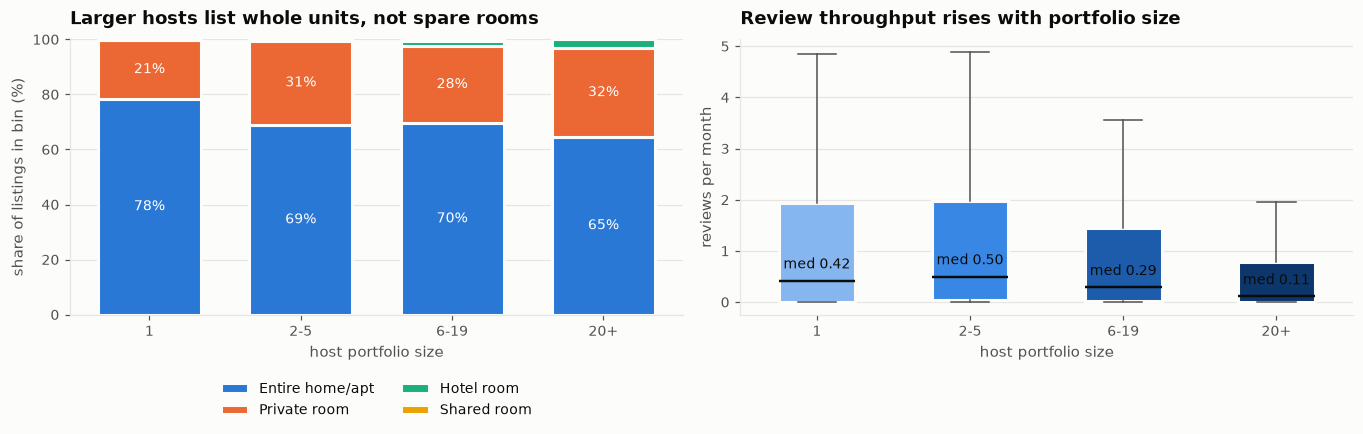

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# ── Left: room type mix within each portfolio-size bin ───────────────────────
rt_ct  = pd.crosstab(raw["_size_bin"], raw["room_type"])
rt_pct = rt_ct.div(rt_ct.sum(axis=1), axis=0) * 100
RT_ORDER  = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]
rt_pct    = rt_pct.reindex(columns=RT_ORDER).fillna(0)
RT_COLORS = dict(zip(RT_ORDER, CAT_ORDER))     # fixed slot per entity

bottom = np.zeros(len(rt_pct))
for rt in RT_ORDER:
    vals = rt_pct[rt].values
    axes[0].bar(BIN_LABELS, vals, bottom=bottom, label=rt, color=RT_COLORS[rt],
                width=0.68, edgecolor=SURFACE, linewidth=2)
    for x, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 6:
            axes[0].annotate(f"{v:.0f}%", xy=(x, b + v / 2), ha="center", va="center",
                             fontsize=9, color="white" if rt != "Hotel room" else INK)
    bottom += vals
axes[0].set_ylim(0, 100)
style_ax(axes[0], "Larger hosts list whole units, not spare rooms",
         "host portfolio size", "share of listings in bin (%)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2)

# ── Right: booking throughput by portfolio size ──────────────────────────────
# reviews_per_month is the standard public proxy for occupancy: a fraction of
# stays leave a review, so it scales with completed bookings.
rpm = raw.dropna(subset=["_size_bin"]).copy()
rpm["reviews_per_month"] = rpm["reviews_per_month"].fillna(0)
data = [rpm.loc[rpm["_size_bin"] == b, "reviews_per_month"].values for b in BIN_LABELS]

bp = axes[1].boxplot(data, tick_labels=BIN_LABELS, showfliers=False, widths=0.5,
                     patch_artist=True, medianprops=dict(color=INK, linewidth=1.6),
                     whiskerprops=dict(color=INK_SOFT, linewidth=1.0),
                     capprops=dict(color=INK_SOFT, linewidth=1.0))
for patch, colr in zip(bp["boxes"], SEQ4):
    patch.set_facecolor(colr); patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
for x, b in enumerate(BIN_LABELS, start=1):
    med = np.median(rpm.loc[rpm["_size_bin"] == b, "reviews_per_month"])
    axes[1].annotate(f"med {med:.2f}", xy=(x, med), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9, color=INK)
style_ax(axes[1], "Review throughput rises with portfolio size",
         "host portfolio size", "reviews per month")

plt.tight_layout(); plt.show()

Two more behavioral gradients, both monotone in portfolio size: large hosts list **entire units**
(not spare rooms) and turn over **more bookings per month**. Combined with proximity to the Strip,
these give a coherent commercial-operation signature that §4 encodes explicitly.

---
# §2 — Cleaning

Every operation below is deliberately conservative: nothing is dropped on the basis of a value
looking odd, and no missing value is filled with an invented estimate unless the fill is paired
with an indicator that tells the model the value was invented.

In [12]:
def clean(df_in: pd.DataFrame) -> pd.DataFrame:
    """Apply the §2 cleaning contract. Pure: returns a new frame, mutates nothing."""
    df = df_in.copy()
    df = df.drop(columns=[c for c in ("neighbourhood_group", "_lic_state", "_size_bin")
                          if c in df.columns])

    # ── price ────────────────────────────────────────────────────────────────
    # Not imputed. Missingness is structural (rate suppressed), so it becomes a
    # feature; the numeric slot is filled with the observed median only so the
    # tensor is finite, and price_missing lets the network discount that slot.
    df["price_missing"] = df["price"].isna().astype(np.float32)
    price_cap  = df["price"].quantile(0.99)
    price_capd = df["price"].clip(upper=price_cap)                # tame the $114k tail
    df["price_log"] = np.log1p(price_capd)                        # additive scale
    df["price_log"] = df["price_log"].fillna(df["price_log"].median())

    # ── reviews ──────────────────────────────────────────────────────────────
    # Null means "never reviewed", which is a state, not a gap. Encode both.
    df["never_reviewed"]    = df["reviews_per_month"].isna().astype(np.float32)
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0.0)

    # ── minimum_nights ───────────────────────────────────────────────────────
    # Capped at p99 (= 32). Everything above the 31-night legal threshold is
    # equivalent for our purposes, and is_31plus (§4) carries that meaning.
    mn_cap = df["minimum_nights"].quantile(0.99)
    df["minimum_nights"] = df["minimum_nights"].fillna(df["minimum_nights"].median()).clip(upper=mn_cap)

    # ── host portfolio size ──────────────────────────────────────────────────
    # 62 nulls; a listing with no recorded host account is treated as a lone listing,
    # the conservative choice (it cannot inflate a host into a large-operator bin).
    df["calculated_host_listings_count"] = df["calculated_host_listings_count"].fillna(1.0)

    # ── name ─────────────────────────────────────────────────────────────────
    # Whitespace normalisation ONLY. No lowercasing, no punctuation stripping, no
    # stopword removal: the sentence transformer in §5 is trained on natural text
    # and casing/punctuation ("MGM Signature 1BR/2BA") carries real signal.
    df["name"] = (df["name"].fillna("")
                            .str.replace(r"[\r\n\t]+", " ", regex=True)
                            .str.replace(r"\s+", " ", regex=True)
                            .str.strip())

    # ── recency (used only for reporting, never as a feature) ────────────────
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

    return df, {"price_cap": float(price_cap), "min_nights_cap": float(mn_cap)}


df, CAPS = clean(raw)

print(f"price capped at 99th pct        : ${CAPS['price_cap']:,.0f}"
      f"   (raw max was ${raw['price'].max():,.0f})")
print(f"minimum_nights capped at 99th pct: {CAPS['min_nights_cap']:.0f} nights")
print(f"price_missing flag set on        : {int(df['price_missing'].sum()):,} listings "
      f"({df['price_missing'].mean():.1%})")
print(f"never_reviewed flag set on       : {int(df['never_reviewed'].sum()):,} listings "
      f"({df['never_reviewed'].mean():.1%})")
print(f"names with whitespace normalised : {int((raw['name'].fillna('') != df['name']).sum()):,}")
print(f"\nshape: {df.shape}  (neighbourhood_group dropped)")

# Post-conditions — the cleaning contract, enforced.
assert df["price_log"].notna().all(),        "price_log must be complete"
assert df["minimum_nights"].notna().all(),   "minimum_nights must be complete"
assert df["reviews_per_month"].notna().all(),"reviews_per_month must be complete"
assert not df["name"].str.contains(r"[\r\n\t]").any(), "control chars remain in name"
assert len(df) == len(raw),                  "cleaning must not drop rows"
print("\nAll cleaning post-conditions hold.")

price capped at 99th pct        : $1,849   (raw max was $114,164)
minimum_nights capped at 99th pct: 32 nights
price_missing flag set on        : 2,965 listings (14.6%)
never_reviewed flag set on       : 5,745 listings (28.3%)
names with whitespace normalised : 514

shape: (20296, 21)  (neighbourhood_group dropped)

All cleaning post-conditions hold.


---
# §3 — Label construction: a Positive-Unlabeled setup

## 3.1 Why this is not ordinary binary classification

We have exactly one trustworthy label: a listing displaying a well-formed Clark County license
number `G##-#####` **is** a permitted operator. That is a positive we can rely on.

What we do not have, anywhere in this file, is a **verified negative**. A blank `license` field
could mean the host never registered, or that they registered and Airbnb never surfaced it, or
that the scrape missed it. `"Exempt"` could be truthful or a shield. Treating either as a negative
would train the model on labels that are wrong for an unknown and probably large fraction of rows.

So the data is:

$$
\underbrace{\{x_i\}_{i \in \mathcal{P}}}_{\text{684 confirmed positives}}
\quad\cup\quad
\underbrace{\{x_i\}_{i \in \mathcal{U}}}_{\text{19{,}612 unlabeled: a mixture of positives and negatives}}
$$

This is the classic **Positive-Unlabeled** setting. The consequence that matters: if you take the
obvious shortcut and train a standard classifier with $\mathcal{U}$ as the negative class, every
hidden positive inside $\mathcal{U}$ is a mislabeled example pulling the decision boundary the
wrong way. The estimator is biased, and the bias does not vanish with more data. §5 uses the
non-negative PU risk estimator, which corrects for it explicitly given the class prior $\pi$.

## 3.2 Why `"Exempt"` cannot be treated as a negative — or as a positive

`"Exempt"` covers at least four genuinely different situations that the data cannot separate:

| Situation | Legitimately exempt? | Would we want it flagged? |
|---|---|---|
| Bona-fide 31+ night residential lease (outside STR rules) | Yes | No |
| Condo-hotel unit covered by a property-wide resort license | Yes | No |
| Commercial operator setting `minimum_nights = 31` on paper while taking shorter stays | No | **Yes** |
| Host who simply typed "Exempt" because the field was required | Unknown | Probably |

Note the evidence from §1.4: `"Exempt"` is claimed by **47% of listings held by 20+ property hosts**
versus **14%** of single-property hosts. Whatever mix of the four rows above it represents, it is
overwhelmingly a large-operator phenomenon. Forcing it to either class would inject exactly the
error PU learning exists to avoid. It stays unlabeled, and the model is allowed to place it
wherever the behavioral evidence puts it.

## 3.3 A third license format — noise inside the positive definition

The project brief specifies positives as `^G\d{2}-\d{5}`. Applying that literally is correct, but
it leaves a wrinkle worth stating out loud, because it is a source of label noise the PU framework
must absorb rather than a bug to be silently patched.

In [13]:
# Inventory of every distinct shape the license field takes.
lic_raw = df["license"].fillna("")
buckets = {
    "Real license  G##-#####":  lic_raw.str.match(r"^G\d{2}-\d{5}"),
    "Lowercase     g##-#####":  lic_raw.str.match(r"^g\d{2}-\d{5}"),
    "Exempt":                   lic_raw.eq("Exempt"),
    "Missing":                  df["license"].isna(),
}
buckets["Other free text"] = ~(buckets["Real license  G##-#####"] | buckets["Lowercase     g##-#####"]
                               | buckets["Exempt"] | buckets["Missing"])

print(f"{'bucket':28s} {'n':>7s}  {'%':>6s}")
print("-" * 45)
for k, m in buckets.items():
    print(f"{k:28s} {int(m.sum()):7,}  {m.mean() * 100:5.1f}%")

print("\nA sample of the 'Other free text' bucket:")
for v in df.loc[buckets["Other free text"], "license"].drop_duplicates().head(12):
    print("   ", v)

bucket                             n       %
---------------------------------------------
Real license  G##-#####          684    3.4%
Lowercase     g##-#####           10    0.0%
Exempt                         6,009   29.6%
Missing                       13,209   65.1%
Other free text                  384    1.9%

A sample of the 'Other free text' bucket:
    2006985.072-260, NV20232701841
    2007213-072-260, NV20232726434
    STR21-00162
    STR-000314, NV20212039147
    STR-000320, NV20212039147
    2007302.072-260, NV20232718789
    STR-000089, NV20222616270
    STR-000042, NV20201765187
    STR-000044, NV20212039147
    2007324.072-260, NV20171474474
    STR-000120, NV20222492666
    STR-000111, NV20232662644


Those `STR-000314, NV20212039147` strings are **also real licenses** — City of Las Vegas / City of
Henderson STR permits plus a Nevada state business ID, a different municipality's format. Ten more
rows carry a lowercase `g63-08409`, which is the county format with a typo.

The brief's regex is the right call and we keep it, for two reasons: the `G##-#####` set is the one
homogeneous, verifiable population (494 distinct licenses), and the ~394 other-format rows are
concentrated in the incorporated cities, which operate separate registration schemes. But those
394 rows now sit in $\mathcal{U}$ while being demonstrably licensed. That is **label noise in the
unlabeled set** — and it is precisely the contamination nnPU is designed to tolerate, since nnPU
already models $\mathcal{U}$ as a $\pi$-weighted mixture containing positives. We quantify the
damage in the §8 robustness check rather than hand-waving it away.

In [14]:
# ── The PU labels ────────────────────────────────────────────────────────────
# y = 1  →  confirmed positive (well-formed Clark County license number)
# y = 0  →  UNLABELED. This is *not* "negative"; see §3.1. Every downstream
#           routine that consumes y treats 0 as "unknown", never as "not commercial".
df["y_pu"] = df["license"].fillna("").str.match(r"^G\d{2}-\d{5}").astype(np.int64)

# Kept for the §8 robustness check only — never used for training.
df["_other_format_license"] = buckets["Other free text"].astype(np.int64)

n_pos, n_unl = int(df["y_pu"].sum()), int((df["y_pu"] == 0).sum())
print(f"Positives  (confirmed licensed) : {n_pos:6,}  ({n_pos / len(df):.2%})")
print(f"Unlabeled  (null / Exempt / other): {n_unl:6,}  ({n_unl / len(df):.2%})")
print(f"Distinct license numbers among positives: {df.loc[df.y_pu == 1, 'license'].nunique():,}")
assert n_pos == 684, f"expected 684 positives, got {n_pos}"

print("\nComposition of the unlabeled pool:")
unl = df[df["y_pu"] == 0]
print(pd.Series({
    "license is null":              int(unl["license"].isna().sum()),
    "license == 'Exempt'":          int((unl["license"] == "Exempt").sum()),
    "other-format license (noise)": int(unl["_other_format_license"].sum()),
}).to_string())

Positives  (confirmed licensed) :    684  (3.37%)
Unlabeled  (null / Exempt / other): 19,612  (96.63%)
Distinct license numbers among positives: 494

Composition of the unlabeled pool:
license is null                 13209
license == 'Exempt'              6009
other-format license (noise)      384


## 3.4 The class prior $\pi$, and why we treat it as an assumption rather than a measurement

nnPU needs $\pi = P(y = 1)$ — the true share of positives in the whole population, *including* the
ones hidden in $\mathcal{U}$. It is not identifiable from PU data without extra assumptions, so
guessing it well matters, and being honest about the guess matters more.

Bounds we can actually defend:

- **Lower bound.** 684/20,296 = **3.4%** if the observed positives were the only ones. Certainly
  too low — the 394 other-format licenses alone prove positives exist in $\mathcal{U}$.
- **Upper bound.** If "commercial-operation-like" is the latent class, §1.3 puts 34.7% of listings
  with 20+ hosts, and adding 6–19 hosts reaches ~54%. So a prior above ~0.5 is implausible.

The brief prescribes a sensitivity sweep over $\pi \in \{0.2, 0.35, 0.5\}$, which straddles that
range sensibly, and §5.4 runs it. $\pi = 0.35$ is carried forward as the default: it is the middle
of the defensible band and closest to the "listings owned by hosts with 6+ properties" share, which
is the most natural reading of the latent class. **Every downstream number should be read as
conditional on that choice**, which is exactly why the sweep is reported rather than buried.

---
# §4 — Feature engineering

Features are grouped by the branch of the network that will consume them (§5). Each one below is
motivated by a mechanism, not by a correlation — an enforcement model whose features cannot be
explained to a hearing officer is not deployable.

In [15]:
STRIP_LAT, STRIP_LON = 36.1147, -115.1728    # Las Vegas Blvd & Flamingo Rd

# Keyword families for the title. Chosen because each maps to a concrete claim about
# how the unit is operated, and each is auditable by a human reading the listing.
# Non-capturing groups throughout: str.contains warns (and behaves differently)
# when a pattern carries capture groups, and we only ever want a boolean here.
NAME_PATTERNS = {
    "name_resort_brand": r"(?i)\b(?:resort|mgm|signature|vdara|palms|caesar|westgate|hilton|marriott|wyndham|hyatt|trump)\b",
    "name_suite":        r"(?i)\b(?:suite|penthouse|villa)\b",
    "name_tower":        r"(?i)\b(?:tower|high[\s-]?rise|condo|highrise)\b",
    "name_strip_view":   r"(?i)(?:strip\s*view|view\s*of\s*(?:the\s*)?strip|balcony)",
    "name_31plus":       r"(?i)(?:31\s*\+|31\s*(?:nights?|days?)|monthly|month[\s-]?to[\s-]?month|long[\s-]?term)",
    "name_luxury":       r"(?i)\b(?:luxur\w*|premium|deluxe|exclusive|upscale)\b",
    "name_pool":         r"(?i)\b(?:pool|spa|hot\s*tub|jacuzzi)\b",
    "name_walk_strip":   r"(?i)(?:walk\w*\s+to\s+(?:the\s+)?strip|steps?\s+(?:to|from)\s+(?:the\s+)?strip|min\w*\s+to\s+(?:the\s+)?strip)",
}

def engineer(d: pd.DataFrame) -> pd.DataFrame:
    """Build every derived feature. Pure; returns a new frame."""
    d = d.copy()

    # ── 1. The 31-night regulatory threshold ─────────────────────────────────
    # Clark County's STR rules apply below 31 nights, so 31 is where the legal
    # boundary sits, not a natural booking preference. Setting minimum_nights to
    # exactly 31 is the canonical way to claim exemption. The raw column is capped
    # at 32, so this binary carries the signal the cap flattens.
    d["is_31plus"] = (raw["minimum_nights"].fillna(2) >= 31).astype(np.float32)

    # ── 2. Host portfolio size ───────────────────────────────────────────────
    hc = d["calculated_host_listings_count"]
    d["host_listings_log"] = np.log1p(hc)          # 1 vs 2 matters more than 500 vs 501
    d["host_size_bin"]     = pd.cut(hc, BIN_EDGES, labels=BIN_LABELS).astype(str)
    d["is_multi_host"]     = (hc >= 2).astype(np.float32)
    d["is_large_host"]     = (hc >= 20).astype(np.float32)

    # ── 3. Booking intensity ─────────────────────────────────────────────────
    # reviews per month divided by days open. A hobbyist renting 20 nights a year
    # and a commercial unit open 365 days can post the same raw review rate; this
    # normalises throughput by exposure. +1 avoids division by zero for listings
    # showing no availability.
    d["booking_intensity"] = d["reviews_per_month"] / (d["availability_365"] + 1)

    # Complementary throughput signals.
    d["reviews_ltm_rate"]  = d["number_of_reviews_ltm"] / (d["availability_365"] + 1)
    d["availability_frac"] = d["availability_365"] / 365.0
    d["always_available"]  = (d["availability_365"] >= 350).astype(np.float32)
    d["reviews_log"]       = np.log1p(d["number_of_reviews"])
    # Share of a listing's lifetime reviews earned in the last 12 months: high means
    # currently-operating inventory, low means a dormant or retired listing.
    d["review_recency"]    = d["number_of_reviews_ltm"] / (d["number_of_reviews"] + 1)

    # ── 4. Spatial ───────────────────────────────────────────────────────────
    d["distance_to_strip"]     = haversine_km(d["latitude"].values, d["longitude"].values)
    d["distance_to_strip_log"] = np.log1p(d["distance_to_strip"])
    d["near_strip"]            = (d["distance_to_strip"] < 2.0).astype(np.float32)

    # ── 5. Title regex flags ─────────────────────────────────────────────────
    nm = d["name"].fillna("")
    for feat, pat in NAME_PATTERNS.items():
        d[feat] = nm.str.contains(pat, regex=True).astype(np.float32)
    # Bedroom count from titles like "3 bed", "2BR", "1 bdrm". Capped at 10; 0 = unstated.
    d["name_bedrooms"] = (nm.str.extract(r"(?i)(\d+)\s*(?:bed(?:room)?s?|br|bd(?:rm)?)\b")[0]
                            .astype(float).fillna(0).clip(upper=10))
    d["name_len"]      = nm.str.len().astype(np.float32)
    d["name_n_words"]  = nm.str.split().str.len().fillna(0).astype(np.float32)

    # ── 6. Price per unit of capacity ────────────────────────────────────────
    d["price_per_bedroom"] = d["price_log"] / (d["name_bedrooms"] + 1)

    return d


feat = engineer(df)

NUMERIC_FEATURES = [
    # pricing
    "price_log", "price_missing", "price_per_bedroom",
    # stay rules
    "minimum_nights", "is_31plus",
    # host portfolio
    "host_listings_log", "is_multi_host", "is_large_host",
    # demand / throughput
    "reviews_log", "reviews_per_month", "number_of_reviews_ltm", "never_reviewed",
    "booking_intensity", "reviews_ltm_rate", "review_recency",
    # supply / exposure
    "availability_365", "availability_frac", "always_available",
    # spatial
    "distance_to_strip", "distance_to_strip_log", "near_strip", "latitude", "longitude",
    # title surface form
    *NAME_PATTERNS.keys(), "name_bedrooms", "name_len", "name_n_words",
]
CATEGORICAL_FEATURES = ["neighbourhood", "room_type", "host_size_bin"]
TEXT_FEATURE         = "name"

print(f"{len(NUMERIC_FEATURES)} numeric features, {len(CATEGORICAL_FEATURES)} categorical, "
      f"1 text field\n")
assert feat[NUMERIC_FEATURES].notna().all().all(), "NaN leaked into the numeric block"
assert np.isfinite(feat[NUMERIC_FEATURES].values).all(), "inf leaked into the numeric block"
print("Cardinality of the categorical block:")
for c in CATEGORICAL_FEATURES:
    print(f"  {c:16s} {feat[c].nunique():2d} levels  →  {sorted(feat[c].unique().tolist())}")

34 numeric features, 3 categorical, 1 text field

Cardinality of the categorical block:
  neighbourhood     7 levels  →  ['Boulder City', 'City of Henderson', 'City of Las Vegas', 'City of Mesquite', 'City of North Las Vegas', 'Nellis AFB', 'Unincorporated Areas']
  room_type         4 levels  →  ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
  host_size_bin     4 levels  →  ['1', '2-5', '20+', '6-19']


In [16]:
# Sanity check: do the engineered features separate the two groups the way the
# mechanism story predicts? This is a face-validity check on the FEATURES, before
# any model exists to blame. Note it is a comparison of positives against the
# unlabeled pool, so it is contaminated by hidden positives by construction.
CHECK = ["host_listings_log", "is_large_host", "is_31plus", "booking_intensity",
         "availability_frac", "distance_to_strip", "price_log", "name_resort_brand",
         "review_recency", "near_strip"]

cmp = pd.DataFrame({
    "positives (licensed)": feat.loc[feat.y_pu == 1, CHECK].mean(),
    "unlabeled":            feat.loc[feat.y_pu == 0, CHECK].mean(),
})
cmp["ratio"] = (cmp["positives (licensed)"] / cmp["unlabeled"].replace(0, np.nan)).round(2)
print(cmp.round(3).to_string())

                   positives (licensed)  unlabeled  ratio
host_listings_log                 1.636      2.464   0.66
is_large_host                     0.117      0.355   0.33
is_31plus                         0.022      0.070   0.31
booking_intensity                 0.066      0.045   1.46
availability_frac                 0.632      0.592   1.07
distance_to_strip                 8.433      7.580   1.11
price_log                         5.506      5.406   1.02
name_resort_brand                 0.006      0.203   0.03
review_recency                    0.371      0.228   1.63
near_strip                        0.000      0.321   0.00


Read the `ratio` column against the direction the business framing predicts, and the §1.4 finding
reappears in the features: confirmed-licensed listings have **smaller** host portfolios, are
**further** from the Strip, and are **less** likely to carry resort branding than the unlabeled
pool. The features are working correctly; they are simply describing "permitted residential STR,"
which is not the same thing as "commercial operation." §9 is where the two are reconciled.

---
# §5 — A multimodal nnPU network in PyTorch

Three branches, because the evidence lives in three different shapes:

| Branch | Input | Why a separate branch |
|---|---|---|
| **Text** | `name`, encoded by a frozen `all-MiniLM-L6-v2` → 384-d | Titles carry operator intent that no regex captures: *"MGM Signature Studio !"* and *"Cozy guest room, quiet street"* differ in ways a keyword list cannot enumerate. Frozen, so 684 positives cannot overfit a 22M-parameter encoder. |
| **Entity** | `neighbourhood`, `room_type`, `host_size_bin` | Low-cardinality categoricals with real interactions. Learned embeddings beat one-hot because the network can place "20+ / Entire home" near "6-19 / Entire home" without being told to. |
| **Numeric** | 32 standardised behavioral, spatial and regex features | The auditable core — every feature explains itself to a hearing officer. |

Concatenated, then two dense layers → a single logit. §8 ablates each branch so the text branch has
to justify its cost.

## 5.1 Text embeddings

The encoder is **frozen**. It runs once over all 20,296 titles, the 384-d vectors are cached to
disk, and the trainable part of the text branch is a single projection. With only 684 positives,
fine-tuning a transformer would memorise them within an epoch.

In [17]:
from sentence_transformers import SentenceTransformer

TEXT_MODEL   = "sentence-transformers/all-MiniLM-L6-v2"
EMB_CACHE    = ARTIFACTS / "name_embeddings_minilm.npy"
TEXT_EMB_DIM = 384

def build_text_embeddings(texts, cache: Path = EMB_CACHE) -> np.ndarray:
    """Encode listing titles once with a frozen sentence transformer; cache to disk.

    Cached by row count so a changed dataset invalidates the cache instead of
    silently reusing embeddings that no longer line up with the frame.
    """
    if cache.exists():
        arr = np.load(cache)
        if arr.shape == (len(texts), TEXT_EMB_DIM):
            print(f"Loaded cached embeddings from {cache}  →  {arr.shape}")
            return arr
        print("Cache shape mismatch — re-encoding.")

    print(f"Encoding {len(texts):,} titles with {TEXT_MODEL} on {DEVICE} …")
    t0 = time.time()
    encoder = SentenceTransformer(TEXT_MODEL, device=str(DEVICE))
    encoder.eval()
    for p in encoder.parameters():      # belt and braces: the encoder never trains
        p.requires_grad_(False)
    with torch.no_grad():
        arr = encoder.encode(list(texts), batch_size=256, show_progress_bar=True,
                             convert_to_numpy=True, normalize_embeddings=True)
    arr = arr.astype(np.float32)
    np.save(cache, arr)
    print(f"Encoded in {time.time() - t0:.1f}s  →  {arr.shape}  (cached to {cache})")
    del encoder
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return arr

set_seed(SEED)
TEXT_EMB = build_text_embeddings(feat[TEXT_FEATURE].tolist())

assert TEXT_EMB.shape == (len(feat), TEXT_EMB_DIM)
assert np.isfinite(TEXT_EMB).all()
print(f"\nEmbedding matrix: {TEXT_EMB.shape}, "
      f"L2 norm per row ≈ {np.linalg.norm(TEXT_EMB, axis=1).mean():.3f} (normalised)")

Loaded cached embeddings from artifacts/name_embeddings_minilm.npy  →  (20296, 384)

Embedding matrix: (20296, 384), L2 norm per row ≈ 1.000 (normalised)


In [18]:
# Do the embeddings actually encode anything relevant? Nearest neighbours of a
# few probe titles, by cosine similarity (rows are L2-normalised, so a dot product).
def nearest_titles(query_idx: int, k: int = 4):
    sims  = TEXT_EMB @ TEXT_EMB[query_idx]
    order = np.argsort(-sims)[1:k + 1]           # skip self
    return [(feat["name"].iloc[j][:62], float(sims[j])) for j in order]

probes = []
for pat in [r"(?i)mgm signature", r"(?i)private room", r"(?i)pool"]:
    hits = feat.index[feat["name"].str.contains(pat, regex=True)]
    if len(hits): probes.append(feat.index.get_loc(hits[0]))

for i in probes:
    print(f'"{feat["name"].iloc[i][:62]}"')
    for t, s in nearest_titles(i):
        print(f"    {s:.3f}  {t}")
    print()

"MGM Signature Studio !"
    0.846  MGM Signature Studio Suite
    0.835  Signature MGM
    0.824  NEW! SIGNATURE STUDIO SUITE - MGM LAS VEGAS
    0.821  MGM Signature Suite

"Private Room in Tropical Las Vegas Vacation Home."
    0.904  Private Room In Las Vegas
    0.904  Private Room in Las Vegas
    0.904  Private room in Las Vegas
    0.893  Private room in Vegas House

"Las Vegas House with Private Pool 2,000 sq ft"
    0.868  Spacious Vegas Home w/private pool
    0.839  Spacious Vegas House w/ Pool
    0.829  Las Vegas Home with a Large Pool
    0.828  Las Vegas 3 Bedroom House with Pool



## 5.2 The non-negative PU risk estimator

### The problem with the obvious approach

Write $\pi = p(y{=}1)$, let $g$ be the network's logit and $\ell$ a margin loss. The risk we
actually want, if we had labelled negatives, is

$$
R(g) \;=\; \pi\,\underbrace{\mathbb{E}_{p}\!\left[\ell\big(g(X), +1\big)\right]}_{R_p^{+}(g)}
      \;+\; (1-\pi)\,\underbrace{\mathbb{E}_{n}\!\left[\ell\big(g(X), -1\big)\right]}_{R_n^{-}(g)} .
$$

We cannot evaluate $R_n^-$: there are no negatives. The way out (du Plessis et al., 2015) is that
the unlabeled marginal is a mixture, $p(x) = \pi\,p_p(x) + (1-\pi)\,p_n(x)$, so the negative term
can be rewritten using quantities we *can* estimate:

$$
(1-\pi)\,R_n^{-}(g) \;=\; \underbrace{\mathbb{E}_{u}\!\left[\ell\big(g(X), -1\big)\right]}_{R_u^{-}(g)}
                       \;-\; \pi\,\underbrace{\mathbb{E}_{p}\!\left[\ell\big(g(X), -1\big)\right]}_{R_p^{-}(g)} ,
$$

giving the **unbiased PU risk**

$$
\widehat{R}_{\mathrm{uPU}}(g) \;=\; \pi\,\widehat{R}_p^{+}(g) \;+\; \widehat{R}_u^{-}(g) \;-\; \pi\,\widehat{R}_p^{-}(g).
$$

### Why uPU breaks on a neural network

The bracketed term $\widehat{R}_u^{-} - \pi \widehat{R}_p^{-}$ estimates $(1-\pi) R_n^- \geq 0$ — a
quantity that is **non-negative by construction**. But it is only an *estimate*. Give a flexible
model enough capacity and it will drive that estimate below zero, because doing so lowers the
objective without bound. The model then chases negative empirical risk, memorising the positives,
and test performance collapses. This is not a hypothetical: §5.3 reproduces it in twenty lines.

### The fix (Kiryo et al., NeurIPS 2017)

Clamp the term at zero, since we know its true value cannot be negative:

$$
\boxed{\;\widehat{R}_{\mathrm{nnPU}}(g) \;=\; \pi\,\widehat{R}_p^{+}(g)
   \;+\; \max\!\Big\{0,\;\; \widehat{R}_u^{-}(g) - \pi\,\widehat{R}_p^{-}(g)\Big\}\;}
$$

with the training rule: when the negative part drops below $-\beta$ (default $\beta = 0$), *stop
descending* and instead take a **gradient-ascent** step along $-\gamma\big(\widehat{R}_u^{-} - \pi
\widehat{R}_p^{-}\big)$ with $\gamma \in (0, 1]$. That pushes the model back into the feasible
region instead of letting it dive further.

We use the **sigmoid loss**, $\ell(z, +1) = \sigma(-z)$ and $\ell(z, -1) = \sigma(z)$, as in the
original paper: it is bounded in $[0,1]$, which keeps the risk terms comparable and makes the
clamp meaningful.

In [19]:
class NonNegativePULoss(nn.Module):
    r"""Non-negative PU risk estimator (Kiryo et al., NeurIPS 2017).

        R_nnPU(g) = pi * Rp+(g)  +  max{0, Ru-(g) - pi * Rp-(g)}

    where, with the sigmoid loss l(z,+1) = sigmoid(-z), l(z,-1) = sigmoid(z):

        Rp+(g) = mean_{x in P} sigmoid(-g(x))     # positives scored as positive
        Rp-(g) = mean_{x in P} sigmoid( g(x))     # positives scored as negative
        Ru-(g) = mean_{x in U} sigmoid( g(x))     # unlabeled scored as negative

    Training rule: while the negative part is >= -beta, descend the whole objective.
    Once it falls below -beta, descend -gamma * (negative part) instead, which is
    gradient ASCENT on the negative part and pushes the estimate back toward zero.

    Args:
        prior: class prior pi = P(y=1) over the whole population. Not identifiable
            from PU data; supplied as an assumption and swept in section 5.4.
        beta:  non-negativity threshold. 0 reproduces the paper's default.
        gamma: step-size discount applied during the correction phase.
    """

    def __init__(self, prior: float, beta: float = 0.0, gamma: float = 1.0):
        super().__init__()
        if not 0.0 < prior < 1.0:
            raise ValueError(f"prior must lie in (0, 1); got {prior}")
        self.prior, self.beta, self.gamma = float(prior), float(beta), float(gamma)

    def forward(self, logits: torch.Tensor, y: torch.Tensor):
        """Returns (loss_to_backprop, objective_to_report, correction_was_applied).

        The two scalars differ only during the correction phase: the reported
        objective stays the true nnPU risk so training curves remain interpretable,
        while the backprop target becomes the ascent direction.
        """
        logits = logits.view(-1)
        y      = y.view(-1).float()
        pos_m, unl_m = y == 1, y == 0
        n_p = pos_m.sum().clamp(min=1)      # clamp guards an all-unlabeled batch
        n_u = unl_m.sum().clamp(min=1)
        has_pos = pos_m.any()

        # sigmoid loss, both label conventions
        loss_pos_as_pos = torch.sigmoid(-logits)   # l(z, +1)
        loss_as_neg     = torch.sigmoid( logits)   # l(z, -1)

        # Rp+ and Rp-: expectations over the positive set
        rp_pos = (loss_pos_as_pos * pos_m).sum() / n_p
        rp_neg = (loss_as_neg     * pos_m).sum() / n_p
        # Ru-: expectation over the unlabeled set
        ru_neg = (loss_as_neg     * unl_m).sum() / n_u

        if not has_pos:
            # Degenerate batch: no positives, so Rp+/Rp- are undefined. Fall back to
            # the unlabeled term alone rather than emitting a garbage gradient.
            zero = torch.zeros((), device=logits.device, dtype=logits.dtype)
            return ru_neg, ru_neg, zero.bool()

        positive_risk = self.prior * rp_pos                 # pi * Rp+
        negative_risk = ru_neg - self.prior * rp_neg        # Ru- - pi * Rp-  (est. of (1-pi)Rn-)

        objective = positive_risk + torch.clamp(negative_risk, min=0.0)   # the nnPU risk

        if negative_risk.item() < -self.beta:
            # Correction phase: ascend the negative part.
            loss = -self.gamma * negative_risk
            corrected = True
        else:
            loss = positive_risk + negative_risk
            corrected = False

        return loss, objective.detach(), corrected


class UnbiasedPULoss(nn.Module):
    """uPU (du Plessis et al., 2015) — nnPU without the clamp. Kept only so section
    5.3 can demonstrate the failure mode nnPU exists to prevent."""

    def __init__(self, prior: float):
        super().__init__()
        self.prior = float(prior)

    def forward(self, logits, y):
        logits, y = logits.view(-1), y.view(-1).float()
        pos_m, unl_m = y == 1, y == 0
        n_p, n_u = pos_m.sum().clamp(min=1), unl_m.sum().clamp(min=1)
        rp_pos = (torch.sigmoid(-logits) * pos_m).sum() / n_p
        rp_neg = (torch.sigmoid( logits) * pos_m).sum() / n_p
        ru_neg = (torch.sigmoid( logits) * unl_m).sum() / n_u
        risk = self.prior * rp_pos + (ru_neg - self.prior * rp_neg)   # may go negative
        return risk, risk.detach(), torch.tensor(False)


print("nnPU and uPU losses defined.")

nnPU and uPU losses defined.


## 5.3 Unit-testing the loss before trusting it

A loss function with a sign error trains silently and produces a plausible-looking ranking. Four
tests below: three closed-form checks against values derived by hand, then a full synthetic
experiment where the hidden labels *are* known, so we can measure what the estimator actually does.

In [20]:
# ── Test 1: analytic value at g(x) = 0 ───────────────────────────────────────
# With every logit zero, sigmoid(0) = 1/2 everywhere, so
#   Rp+ = Rp- = Ru- = 1/2
#   positive_risk = pi/2 ;  negative_risk = 1/2 - pi/2
#   objective     = pi/2 + max(0, 1/2 - pi/2) = 1/2   for every pi in (0, 1).
# The risk must be exactly 0.5 regardless of the prior — a strong check that the
# pi-weighting is wired up correctly.
print("Test 1 — analytic value at logits = 0")
z = torch.zeros(1000)
y = torch.cat([torch.ones(200), torch.zeros(800)])
for pi in (0.05, 0.2, 0.35, 0.5, 0.9):
    _, obj, corr = NonNegativePULoss(prior=pi)(z, y)
    assert abs(obj.item() - 0.5) < 1e-6, f"pi={pi}: expected 0.5, got {obj.item()}"
    assert not corr, "no correction should trigger at logits = 0"
    print(f"    pi={pi:<5} objective={obj.item():.6f}  ✓ (expected 0.500000)")


# ── Test 2: the clamp engages exactly when the negative part goes negative ───
# Push positives to a large positive logit and unlabeled to a large negative one.
# Then Ru- -> 0 and Rp- -> 0, but pi*Rp- is subtracted from an almost-zero Ru-,
# so the negative part must be <= 0 and the correction must fire.
print("\nTest 2 — clamp engages when the negative risk goes below -beta")
logits = torch.cat([torch.full((200,), 8.0), torch.full((800,), -8.0)])
labels = torch.cat([torch.ones(200),         torch.zeros(800)])
loss, obj, corr = NonNegativePULoss(prior=0.35)(logits, labels)
print(f"    correction applied : {bool(corr)}")
print(f"    reported objective : {obj.item():.6f}   (clamped, so >= pi*Rp+ >= 0)")
print(f"    backprop target    : {loss.item():.6f}   (= -gamma * negative_risk, so > 0)")
assert bool(corr),        "clamp should have engaged"
assert obj.item() >= 0.0, "the nnPU objective is non-negative by construction"
assert loss.item() > 0.0, "during correction the backprop target is -gamma*neg_risk > 0"

# uPU on the same input goes negative — the pathology nnPU rules out.
u_loss, _, _ = UnbiasedPULoss(prior=0.35)(logits, labels)
print(f"    uPU on the same input: {u_loss.item():.6f}  ← negative, unbounded below")
assert u_loss.item() < 0.0, "uPU should go negative here; that is the whole point"


# ── Test 3: gradients are finite and point the right way ────────────────────
print("\nTest 3 — gradient sanity")
z = torch.randn(500, requires_grad=True)
y = torch.cat([torch.ones(100), torch.zeros(400)])
loss, _, _ = NonNegativePULoss(prior=0.35)(z, y)
loss.backward()
assert z.grad is not None and torch.isfinite(z.grad).all(), "non-finite gradient"
# Descending the loss must raise the logits of the positives on average.
print(f"    mean grad on positives  : {z.grad[:100].mean().item():+.6f}  "
      f"(negative → gradient descent pushes positive logits UP)")
print(f"    mean grad on unlabeled  : {z.grad[100:].mean().item():+.6f}")
assert z.grad[:100].mean().item() < 0, "positives should be pushed toward a higher logit"
print("\nAll closed-form tests passed.")

Test 1 — analytic value at logits = 0


    pi=0.05  objective=0.500000  ✓ (expected 0.500000)
    pi=0.2   objective=0.500000  ✓ (expected 0.500000)
    pi=0.35  objective=0.500000  ✓ (expected 0.500000)
    pi=0.5   objective=0.500000  ✓ (expected 0.500000)
    pi=0.9   objective=0.500000  ✓ (expected 0.500000)

Test 2 — clamp engages when the negative risk goes below -beta
    correction applied : True
    reported objective : 0.000117   (clamped, so >= pi*Rp+ >= 0)
    backprop target    : 0.349547   (= -gamma * negative_risk, so > 0)
    uPU on the same input: -0.349430  ← negative, unbounded below

Test 3 — gradient sanity


    mean grad on positives  : -0.001415  (negative → gradient descent pushes positive logits UP)
    mean grad on unlabeled  : +0.000522

All closed-form tests passed.


### Test 4 — end-to-end, on synthetic data where the hidden labels *are* known

One design note first, because it decides whether this test shows anything at all.

uPU only fails when the model is **flexible enough, relative to the number of labelled positives,
to isolate them from the unlabeled pool**. In a low-dimensional problem it simply cannot: with two
features, a point near a labelled positive is unavoidably scored like one, the input space acts as
its own regulariser, and uPU and nnPU come out level with the empirical risk never going negative.
That version of this experiment demonstrates nothing.

So the synthetic problem is built in the regime that actually matters — and it is the regime this
notebook is in: **100 features of which only 5 carry signal, 2,000 points, and 10% of positives
revealed** (70 labelled positives). Compare that with the real setting in §5.4: 384-dimensional
text embeddings plus 34 numeric features, 684 positives, a multi-layer network. Enough room to
memorise, which is precisely when the clamp starts to matter.

In [21]:
# ── Test 4: end-to-end on synthetic data where the hidden labels ARE known ──
# The learner sees ONLY a random subset of the positives as labelled and everything
# else as unlabeled — exactly the real setting — but the true labels are kept aside
# so we can score what each estimator actually learned about the hidden positives.

SYN = dict(n=2000, d=100, n_signal=5, prior=0.35, label_frac=0.10, sep=0.35)

def make_synthetic_pu(n, d, n_signal, prior, label_frac, sep, seed=0):
    """Return (X, y_pu, y_true). y_pu marks only the REVEALED positives.

    Signal lives in the first `n_signal` dimensions; the remaining d - n_signal are
    pure noise. That gives a flexible model plenty of room to memorise the labelled
    positives, which is the condition under which uPU breaks down.
    """
    rng   = np.random.default_rng(seed)
    n_pos = int(n * prior)
    mu = np.zeros(d); mu[:n_signal] = sep
    Xp = rng.normal( mu, 1.0, size=(n_pos,     d))
    Xn = rng.normal(-mu, 1.0, size=(n - n_pos, d))
    X      = np.vstack([Xp, Xn]).astype(np.float32)
    y_true = np.concatenate([np.ones(n_pos), np.zeros(n - n_pos)]).astype(np.int64)
    y_pu   = np.zeros(n, dtype=np.int64)
    y_pu[rng.choice(n_pos, size=int(n_pos * label_frac), replace=False)] = 1
    order = rng.permutation(n)
    return X[order], y_pu[order], y_true[order]


def train_synthetic(loss_fn, X, y_pu, epochs=100, width=256, seed=0):
    """Train an MLP on synthetic PU data; track the reported risk each epoch."""
    torch.manual_seed(seed)
    d = X.shape[1]
    net = nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                        nn.Linear(width, width), nn.ReLU(),
                        nn.Linear(width, 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    Xt, yt = torch.from_numpy(X), torch.from_numpy(y_pu)
    history = []
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            idx = perm[i:i + 256]
            opt.zero_grad()
            loss, _, _ = loss_fn(net(Xt[idx]), yt[idx])
            loss.backward(); opt.step()
        with torch.no_grad():
            _, obj, _ = loss_fn(net(Xt), yt)
        history.append(obj.item())
    with torch.no_grad():
        return net(Xt).view(-1).numpy(), history


set_seed(SEED)
TRUE_PRIOR = SYN["prior"]
Xs, y_pu_s, y_true_s = make_synthetic_pu(**SYN, seed=SEED)
print(f"Synthetic: {SYN['n']:,} points in {SYN['d']}-D ({SYN['n_signal']} signal dims, "
      f"{SYN['d'] - SYN['n_signal']} noise)")
print(f"  true prior {TRUE_PRIOR} | {y_pu_s.sum()} revealed positives | "
      f"{int(y_true_s.sum() - y_pu_s.sum())} positives hidden inside U\n")

from sklearn.metrics import roc_auc_score

# Three seeds each: a single seed cannot separate a real effect from initialisation luck.
SYN_SEEDS = [SEED, SEED + 1, SEED + 2]
runs = {"nnPU (clamped)": [], "uPU (unclamped)": []}
for sd in SYN_SEEDS:
    for name, lf in (("nnPU (clamped)",  NonNegativePULoss(prior=TRUE_PRIOR)),
                     ("uPU (unclamped)", UnbiasedPULoss(prior=TRUE_PRIOR))):
        sc, hist = train_synthetic(lf, Xs, y_pu_s, seed=sd)
        runs[name].append({"scores": sc, "hist": hist,
                           "auc": roc_auc_score(y_true_s, sc), "min_risk": min(hist)})

res = pd.DataFrame([{
    "estimator":            name,
    "AUC vs true y (mean)": np.mean([r["auc"] for r in rs]),
    "AUC sd":               np.std([r["auc"] for r in rs]),
    "final risk":           np.mean([r["hist"][-1] for r in rs]),
    "min risk seen":        np.mean([r["min_risk"] for r in rs]),
} for name, rs in runs.items()]).round(4)
print(res.to_string(index=False))

Synthetic: 2,000 points in 100-D (5 signal dims, 95 noise)
  true prior 0.35 | 70 revealed positives | 630 positives hidden inside U



      estimator  AUC vs true y (mean)  AUC sd  final risk  min risk seen
 nnPU (clamped)                0.7821  0.0121      0.0006         0.0005
uPU (unclamped)                0.7186  0.0143     -0.3166        -0.3166


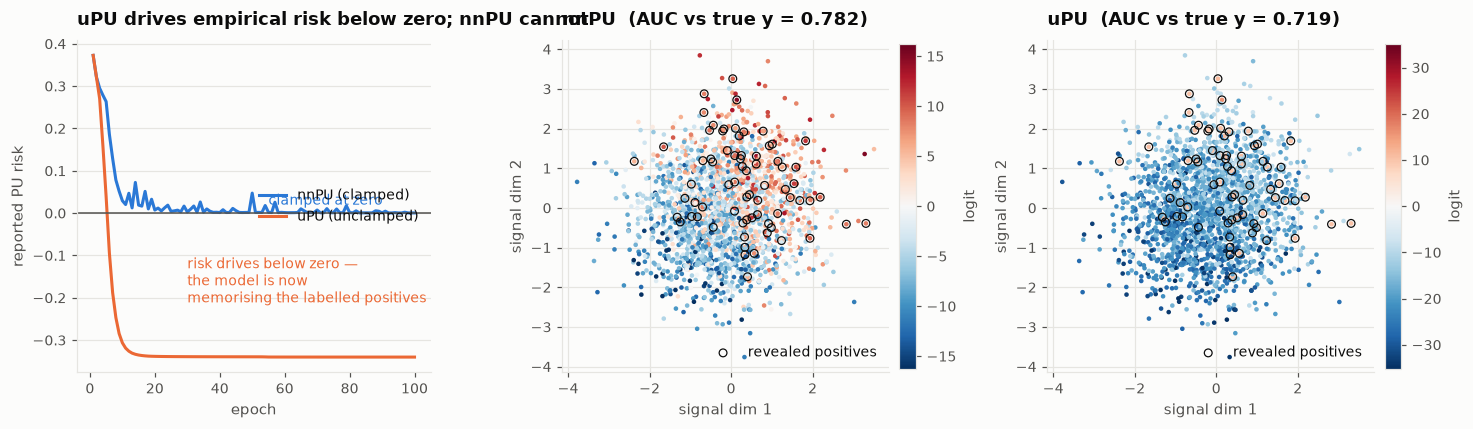

nnPU risk floor   : +0.0005  (clamped at zero, as derived)
uPU  risk floor   : -0.3166  (unbounded below — overfitting)
AUC vs true labels: nnPU 0.7821 ± 0.0121  vs  uPU 0.7186 ± 0.0143   (gap +0.0635 over 3 seeds)

The clamp is not cosmetic: it is what stops the estimator chasing a risk that cannot exist,
and recovering the positives hidden in U is what that buys.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

# Representative run (first seed) for the curves and score fields.
nn_hist, up_hist     = runs["nnPU (clamped)"][0]["hist"],   runs["uPU (unclamped)"][0]["hist"]
nn_scores, up_scores = runs["nnPU (clamped)"][0]["scores"], runs["uPU (unclamped)"][0]["scores"]

# ── Left: the training risk curves ───────────────────────────────────────────
ep = np.arange(1, len(nn_hist) + 1)
axes[0].plot(ep, nn_hist, color=CAT["blue"],   label="nnPU (clamped)")
axes[0].plot(ep, up_hist, color=CAT["orange"], label="uPU (unclamped)")
axes[0].axhline(0, color=INK_SOFT, linewidth=1.0)
axes[0].annotate("risk drives below zero —\nthe model is now\nmemorising the labelled positives",
                 xy=(len(ep) * 0.30, min(up_hist) * 0.62), fontsize=9, color=CAT["orange"])
axes[0].annotate("clamped at zero", xy=(len(ep) * 0.55, 0.02), fontsize=9, color=CAT["blue"])
style_ax(axes[0], "uPU drives empirical risk below zero; nnPU cannot",
         "epoch", "reported PU risk")
axes[0].legend(loc="center right")

# ── Middle & right: score fields, projected onto the two leading signal dims ─
# The problem is 100-D; these are the only two axes that carry any signal, so this
# projection is the honest 2-D view of what each model learned.
for ax, sc, ttl, auc in ((axes[1], nn_scores, "nnPU",
                          res.loc[0, "AUC vs true y (mean)"]),
                         (axes[2], up_scores, "uPU",
                          res.loc[1, "AUC vs true y (mean)"])):
    lim = np.percentile(np.abs(sc), 99)
    im = ax.scatter(Xs[:, 0], Xs[:, 1], c=sc, cmap="RdBu_r", s=9, linewidths=0,
                    vmin=-lim, vmax=lim)          # diverging: two opposite poles, neutral middle
    lab = y_pu_s == 1
    ax.scatter(Xs[lab, 0], Xs[lab, 1], s=26, facecolors="none",
               edgecolors=INK, linewidths=0.8, label="revealed positives")
    style_ax(ax, f"{ttl}  (AUC vs true y = {auc:.3f})",
             "signal dim 1", "signal dim 2", xgrid=True)
    ax.legend(loc="lower right")
    plt.colorbar(im, ax=ax, label="logit", fraction=0.046, pad=0.03)

plt.tight_layout(); plt.show()

# ── Assertions ───────────────────────────────────────────────────────────────
# Hard-assert only what the mathematics guarantees: the nnPU objective is
# non-negative by construction, and uPU's is not bounded below at all.
nn_row, up_row = res.loc[0], res.loc[1]
assert nn_row["min risk seen"] >= -1e-6, "the nnPU objective must never go negative"
assert up_row["min risk seen"] <  0.0,   "uPU should go negative in this regime — that is the point"

gap = nn_row["AUC vs true y (mean)"] - up_row["AUC vs true y (mean)"]
print(f"nnPU risk floor   : {nn_row['min risk seen']:+.4f}  (clamped at zero, as derived)")
print(f"uPU  risk floor   : {up_row['min risk seen']:+.4f}  (unbounded below — overfitting)")
print(f"AUC vs true labels: nnPU {nn_row['AUC vs true y (mean)']:.4f} "
      f"± {nn_row['AUC sd']:.4f}  vs  uPU {up_row['AUC vs true y (mean)']:.4f} "
      f"± {up_row['AUC sd']:.4f}   (gap {gap:+.4f} over {len(SYN_SEEDS)} seeds)")
print("\nThe clamp is not cosmetic: it is what stops the estimator chasing a risk that "
      "cannot exist,\nand recovering the positives hidden in U is what that buys.")

Read the left panel first: uPU's reported risk dives well below zero and keeps going. It is
"optimising" an estimate of a quantity — $(1-\pi)R_n^-$ — that is non-negative in reality, so every
step past zero is the model buying a lower objective with pure overfitting. nnPU's curve flattens
against zero exactly as the derivation says it must.

The two score fields show what that costs. Projected onto the two signal dimensions, nnPU spreads
high scores across the whole positive region, including the positives it was never shown; uPU has
contorted itself around the 70 revealed points and generalises worse to the hidden ones. The clamp
is a one-line change with a measurable payoff.

A caveat worth keeping: this gap is a property of the *regime*, not a law. In the low-dimensional
version of this experiment both estimators tie and uPU's risk never goes negative at all. nnPU
earns its place when the model has room to memorise — which, with 384-dimensional embeddings and
684 positives, is where §5.4 puts us.

## 5.4 Model architecture

In [23]:
class MultimodalPUNet(nn.Module):
    """Text + entity + numeric → fusion MLP → one logit.

    Branch switches exist so section 8 can ablate each modality with identical
    training code rather than a second, subtly different model.
    """

    def __init__(self, n_numeric: int, cat_cardinalities: list[int], text_dim: int = TEXT_EMB_DIM,
                 emb_dim: int = 16, hidden: int = 128, dropout: float = 0.3,
                 use_text: bool = True, use_entity: bool = True, use_numeric: bool = True):
        super().__init__()
        if not (use_text or use_entity or use_numeric):
            raise ValueError("at least one branch must be enabled")
        self.use_text, self.use_entity, self.use_numeric = use_text, use_entity, use_numeric
        fused_dim = 0

        # ── Text branch: project the FROZEN 384-d embedding down ─────────────
        # Only this projection trains. LayerNorm keeps the branch on the same scale
        # as the others so fusion is not dominated by whichever branch is largest.
        if use_text:
            text_out = max(hidden // 2, 32)
            self.text_proj = nn.Sequential(
                nn.Linear(text_dim, text_out), nn.LayerNorm(text_out), nn.ReLU(), nn.Dropout(dropout))
            fused_dim += text_out

        # ── Entity branch: one embedding table per categorical ───────────────
        if use_entity:
            self.embeddings = nn.ModuleList([nn.Embedding(c, emb_dim) for c in cat_cardinalities])
            fused_dim += emb_dim * len(cat_cardinalities)

        # ── Numeric branch ───────────────────────────────────────────────────
        if use_numeric:
            num_out = max(hidden // 2, 32)
            self.numeric_mlp = nn.Sequential(
                nn.Linear(n_numeric, num_out), nn.BatchNorm1d(num_out), nn.ReLU(), nn.Dropout(dropout))
            fused_dim += num_out

        # ── Fusion: two dense layers, then a single logit ────────────────────
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, hidden),     nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),   nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )
        self.apply(self._init)

    @staticmethod
    def _init(m):
        """He init for the ReLU stack; small-normal for embedding tables."""
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.05)

    def forward(self, x_num, x_cat, x_text):
        parts = []
        if self.use_text:    parts.append(self.text_proj(x_text))
        if self.use_entity:  parts.extend(emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings))
        if self.use_numeric: parts.append(self.numeric_mlp(x_num))
        return self.fusion(torch.cat(parts, dim=1)).squeeze(-1)


_probe = MultimodalPUNet(n_numeric=len(NUMERIC_FEATURES), cat_cardinalities=[7, 4, 4])
print(_probe)
print(f"\ntrainable parameters: {sum(p.numel() for p in _probe.parameters() if p.requires_grad):,}")
print(f"frozen encoder parameters (not counted, never updated): ~22.7M")
del _probe

MultimodalPUNet(
  (text_proj): Sequential(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (embeddings): ModuleList(
    (0): Embedding(7, 16)
    (1-2): 2 x Embedding(4, 16)
  )
  (numeric_mlp): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=176, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

trainable parameters: 58,353
frozen encoder parameters (not counted, never updated): ~22.7M


## 5.5 Splits and tensors

Two splits are built:

- **Stratified** (the brief's specification, and the primary reporting split): 60/20/20 stratified
  on the PU label so all three folds carry the same share of the 684 positives.
- **Host-grouped** (a robustness check reported in §8): the same proportions, but every listing
  belonging to one host lands in exactly one fold. This matters here — the largest host owns 537
  listings, so under a random split near-duplicate listings from the same account appear on both
  sides and the model can score a test listing by having memorised its siblings. The gap between
  the two numbers measures how much of the headline AUC is host memorisation.

In [24]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

# ── Encode categoricals to contiguous integer codes ──────────────────────────
CAT_MAPS = {c: {v: i for i, v in enumerate(sorted(feat[c].astype(str).unique()))}
            for c in CATEGORICAL_FEATURES}
CAT_CARD = [len(CAT_MAPS[c]) for c in CATEGORICAL_FEATURES]

X_num_all  = feat[NUMERIC_FEATURES].to_numpy(dtype=np.float32)
X_cat_all  = np.stack([feat[c].astype(str).map(CAT_MAPS[c]).to_numpy() for c in CATEGORICAL_FEATURES],
                      axis=1).astype(np.int64)
X_text_all = TEXT_EMB
y_all      = feat["y_pu"].to_numpy(dtype=np.int64)
groups_all = feat["host_id"].fillna(-feat.index.to_series() - 1).to_numpy()  # null hosts → unique groups

# ── Split A: stratified 60/20/20 (primary) ──────────────────────────────────
idx = np.arange(len(feat))
idx_tr, idx_tmp = train_test_split(idx,     test_size=0.40, stratify=y_all,          random_state=SEED)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, stratify=y_all[idx_tmp], random_state=SEED)
SPLIT_STRAT = {"train": idx_tr, "val": idx_va, "test": idx_te}

# ── Split B: host-grouped, positive-stratified (robustness) ─────────────────
sgkf         = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds        = list(sgkf.split(idx, y_all, groups_all))
g_tr, g_ho   = folds[0][0], folds[0][1]
g_va, g_te   = np.array_split(g_ho, 2)
SPLIT_GROUP  = {"train": g_tr, "val": g_va, "test": g_te}

split_report = pd.DataFrame({
    name: {f"{k} n": len(v) for k, v in sp.items()} |
          {f"{k} positives": int(y_all[v].sum()) for k, v in sp.items()}
    for name, sp in [("stratified", SPLIT_STRAT), ("host-grouped", SPLIT_GROUP)]
})
print(split_report.to_string(), "\n")

leak = len(set(groups_all[SPLIT_STRAT["train"]]) & set(groups_all[SPLIT_STRAT["test"]]))
print(f"Hosts appearing in BOTH train and test under the stratified split : {leak:,}")
print(f"…under the host-grouped split                                     : "
      f"{len(set(groups_all[SPLIT_GROUP['train']]) & set(groups_all[SPLIT_GROUP['test']])):,}")
print("\nThat first number is the leakage the §8 robustness check quantifies.")

                 stratified  host-grouped
train n               12177         16239
val n                  4059          2029
test n                 4060          2028
train positives         410           547
val positives           137            69
test positives          137            68 

Hosts appearing in BOTH train and test under the stratified split : 1,085
…under the host-grouped split                                     : 0

That first number is the leakage the §8 robustness check quantifies.


In [25]:
@dataclass
class Tensors:
    """Model-ready tensors for one split, already resident on the target device."""
    num: torch.Tensor; cat: torch.Tensor; text: torch.Tensor; y: torch.Tensor
    def __len__(self): return len(self.y)


def make_tensors(split: dict, device=DEVICE):
    """Standardise numerics on TRAIN ONLY, then move every fold to the device.

    Fitting the scaler on train alone is what keeps validation and test honest;
    fitting on the full frame would leak the test distribution into training.
    """
    scaler = StandardScaler().fit(X_num_all[split["train"]])
    out = {}
    for name, ix in split.items():
        out[name] = Tensors(
            num  = torch.tensor(scaler.transform(X_num_all[ix]), dtype=torch.float32, device=device),
            cat  = torch.tensor(X_cat_all[ix],                                        device=device),
            text = torch.tensor(X_text_all[ix], dtype=torch.float32,                  device=device),
            y    = torch.tensor(y_all[ix],                                            device=device),
        )
    return out, scaler


DATA_STRAT, SCALER_STRAT = make_tensors(SPLIT_STRAT)
DATA_GROUP, SCALER_GROUP = make_tensors(SPLIT_GROUP)

for k, t in DATA_STRAT.items():
    print(f"{k:6s} num{tuple(t.num.shape)}  cat{tuple(t.cat.shape)}  "
          f"text{tuple(t.text.shape)}  positives={int(t.y.sum())}")
print(f"\nAll tensors on {DEVICE}. Batching is index-based on-device — no DataLoader "
      f"overhead, and the whole dataset fits in memory many times over.")

train  num(12177, 34)  cat(12177, 3)  text(12177, 384)  positives=410
val    num(4059, 34)  cat(4059, 3)  text(4059, 384)  positives=137
test   num(4060, 34)  cat(4060, 3)  text(4060, 384)  positives=137

All tensors on mps. Batching is index-based on-device — no DataLoader overhead, and the whole dataset fits in memory many times over.


## 5.6 The training loop

Batches are drawn by permuting indices on-device rather than through a `DataLoader`: the dataset is
small enough to live entirely in GPU memory, and the nnPU loss needs both positives and unlabeled
examples in every batch, which index-based sampling makes easy to guarantee.

In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score

@dataclass
class TrainConfig:
    lr: float = 1e-3
    weight_decay: float = 1e-4
    dropout: float = 0.3
    hidden: int = 128
    emb_dim: int = 16
    batch_size: int = 128
    prior: float = 0.35
    beta: float = 0.0
    gamma: float = 1.0
    max_epochs: int = 60
    patience: int = 8
    use_text: bool = True
    use_entity: bool = True
    use_numeric: bool = True


def pu_auc(model, data: Tensors) -> float:
    """AUC of held-out positives against the unlabeled pool.

    This is a PU proxy, not a true AUC: the 'negatives' contain hidden positives,
    so the value is pessimistically biased. It is still monotone in real ranking
    quality, which is all a model-selection criterion needs to be. Section 8
    discusses the bias in detail.
    """
    model.eval()
    with torch.no_grad():
        s = model(data.num, data.cat, data.text).cpu().numpy()
    y = data.y.cpu().numpy()
    return float(roc_auc_score(y, s)) if 0 < y.sum() < len(y) else float("nan")


def train_pu_model(cfg: TrainConfig, data: dict, seed: int = SEED, verbose: bool = False,
                   trial=None):
    """Train one nnPU model with early stopping on validation PU-AUC.

    Returns (best_model, history). The model is restored to its best-validation
    weights before being returned, so the caller never sees an over-trained net.
    """
    set_seed(seed)
    tr, va = data["train"], data["val"]

    model = MultimodalPUNet(
        n_numeric=tr.num.shape[1], cat_cardinalities=CAT_CARD, emb_dim=cfg.emb_dim,
        hidden=cfg.hidden, dropout=cfg.dropout, use_text=cfg.use_text,
        use_entity=cfg.use_entity, use_numeric=cfg.use_numeric,
    ).to(DEVICE)

    opt      = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.max_epochs)
    criterion = NonNegativePULoss(prior=cfg.prior, beta=cfg.beta, gamma=cfg.gamma)

    best_auc, best_state, best_epoch, bad = -np.inf, None, 0, 0
    history = {"train_risk": [], "val_auc": [], "corrections": []}
    n = len(tr)

    for epoch in range(cfg.max_epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        epoch_risk, n_corr, n_batch = 0.0, 0, 0

        for i in range(0, n, cfg.batch_size):
            b = perm[i:i + cfg.batch_size]
            if len(b) < 8:                     # skip a ragged tail (BatchNorm needs >1)
                continue
            opt.zero_grad()
            logits = model(tr.num[b], tr.cat[b], tr.text[b])
            loss, obj, corrected = criterion(logits, tr.y[b])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # nnPU corrections can spike
            opt.step()
            epoch_risk += obj.item(); n_corr += int(bool(corrected)); n_batch += 1

        sched.step()
        v_auc = pu_auc(model, va)
        history["train_risk"].append(epoch_risk / max(n_batch, 1))
        history["val_auc"].append(v_auc)
        history["corrections"].append(n_corr / max(n_batch, 1))

        if trial is not None:                  # Optuna pruning hook
            trial.report(v_auc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if v_auc > best_auc + 1e-5:
            best_auc, best_epoch, bad = v_auc, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg.patience:
                if verbose: print(f"  early stop at epoch {epoch} (best {best_epoch})")
                break

        if verbose and epoch % 10 == 0:
            print(f"  epoch {epoch:3d}  risk {history['train_risk'][-1]:.4f}  "
                  f"val PU-AUC {v_auc:.4f}  corrections {history['corrections'][-1]:.0%}")

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_val_auc"], history["best_epoch"] = best_auc, best_epoch
    return model, history


print("Training loop ready. Running a reference fit at the default configuration …\n")
t0 = time.time()
ref_model, ref_hist = train_pu_model(TrainConfig(), DATA_STRAT, verbose=True)
print(f"\nbest val PU-AUC {ref_hist['best_val_auc']:.4f} at epoch {ref_hist['best_epoch']} "
      f"({time.time() - t0:.1f}s)")

Training loop ready. Running a reference fit at the default configuration …



  epoch   0  risk 0.2477  val PU-AUC 0.9279  corrections 23%


  epoch  10  risk 0.0179  val PU-AUC 0.9735  corrections 47%


  early stop at epoch 14 (best 6)

best val PU-AUC 0.9744 at epoch 6 (10.8s)


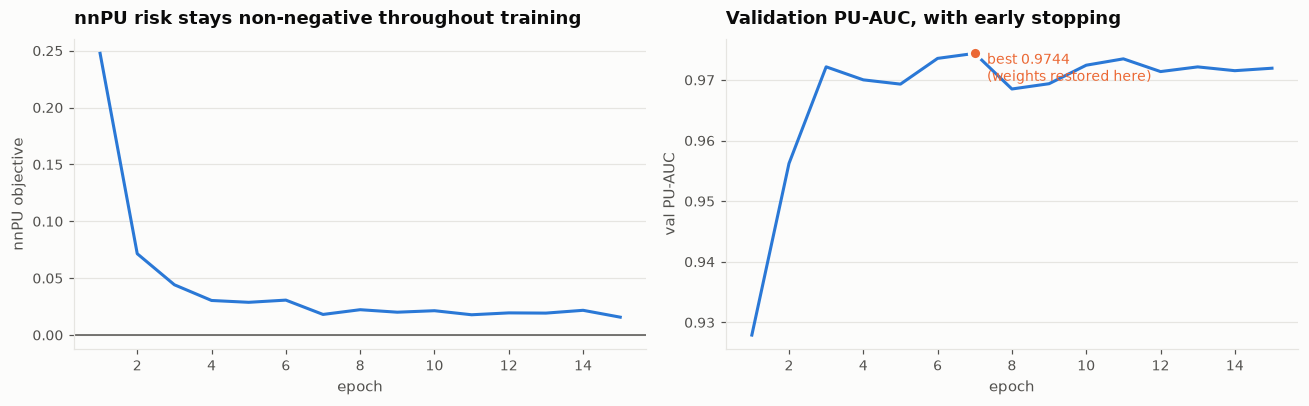

Batches hitting the non-negativity correction: 47.4% on average across epochs.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ep = np.arange(1, len(ref_hist["train_risk"]) + 1)

axes[0].plot(ep, ref_hist["train_risk"], color=CAT["blue"])
axes[0].axhline(0, color=INK_SOFT, linewidth=1.0)
style_ax(axes[0], "nnPU risk stays non-negative throughout training", "epoch", "nnPU objective")

axes[1].plot(ep, ref_hist["val_auc"], color=CAT["blue"])
axes[1].plot([ref_hist["best_epoch"] + 1], [ref_hist["best_val_auc"]], "o",
             color=CAT["orange"], markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
axes[1].annotate(f"best {ref_hist['best_val_auc']:.4f}\n(weights restored here)",
                 xy=(ref_hist["best_epoch"] + 1, ref_hist["best_val_auc"]),
                 xytext=(8, -18), textcoords="offset points", fontsize=9, color=CAT["orange"])
style_ax(axes[1], "Validation PU-AUC, with early stopping", "epoch", "val PU-AUC")

plt.tight_layout(); plt.show()
print(f"Batches hitting the non-negativity correction: "
      f"{np.mean(ref_hist['corrections']):.1%} on average across epochs.")

## 5.7 Sensitivity to the class prior $\pi$

$\pi$ is an assumption, not a measurement (§3.4). If conclusions swing wildly with it, the model is
not decision-grade. The sweep below is the honest way to report that exposure.

In [28]:
PRIORS = [0.2, 0.35, 0.5]
prior_rows, prior_hists, prior_models = [], {}, {}

for pi in PRIORS:
    t0 = time.time()
    m, h = train_pu_model(TrainConfig(prior=pi), DATA_STRAT)
    te = DATA_STRAT["test"]
    m.eval()
    with torch.no_grad():
        s_te = m(te.num, te.cat, te.text).cpu().numpy()
    y_te = te.y.cpu().numpy()

    prior_hists[pi], prior_models[pi] = h, m
    prior_rows.append({
        "prior pi":       pi,
        "val PU-AUC":     h["best_val_auc"],
        "test PU-AUC":    roc_auc_score(y_te, s_te),
        "test PU-AP":     average_precision_score(y_te, s_te),
        "best epoch":     h["best_epoch"],
        "correction %":   np.mean(h["corrections"]),
        "mean P(pos)":    float(np.mean(expit(s_te))),
        "seconds":        time.time() - t0,
    })

prior_df = pd.DataFrame(prior_rows).round(4)
print(prior_df.to_string(index=False))

# Do the three priors agree on the RANKING? That is what an enforcement queue consumes.
from scipy.stats import spearmanr
te = DATA_STRAT["test"]
score_by_prior = {}
for pi, m in prior_models.items():
    m.eval()
    with torch.no_grad():
        score_by_prior[pi] = m(te.num, te.cat, te.text).cpu().numpy()

print("\nSpearman rank correlation between the test rankings each prior produces:")
rank_corr = pd.DataFrame(
    [[spearmanr(score_by_prior[a], score_by_prior[b]).statistic for b in PRIORS] for a in PRIORS],
    index=[f"pi={p}" for p in PRIORS], columns=[f"pi={p}" for p in PRIORS])
print(rank_corr.round(3).to_string())

 prior pi  val PU-AUC  test PU-AUC  test PU-AP  best epoch  correction %  mean P(pos)  seconds
     0.20      0.8170       0.8140      0.1614           1        0.1312       0.0000   6.9807
     0.35      0.9732       0.9745      0.5242           5        0.4725       0.3166   9.2870
     0.50      0.9611       0.9631      0.4227          10        0.4759       0.4969  12.4215

Spearman rank correlation between the test rankings each prior produces:
         pi=0.2  pi=0.35  pi=0.5
pi=0.2    1.000    0.625   0.564
pi=0.35   0.625    1.000   0.981
pi=0.5    0.564    0.981   1.000


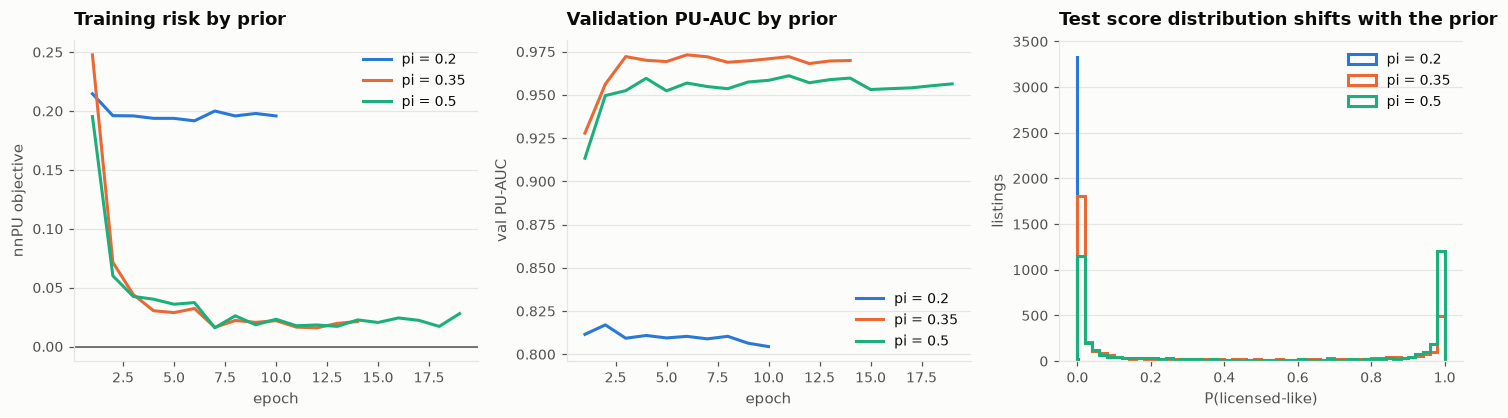

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
PRIOR_COLORS = dict(zip(PRIORS, CAT_ORDER[:3]))    # fixed slot per prior, never by rank

for pi in PRIORS:
    h = prior_hists[pi]
    axes[0].plot(np.arange(1, len(h["train_risk"]) + 1), h["train_risk"],
                 color=PRIOR_COLORS[pi], label=f"pi = {pi}")
    axes[1].plot(np.arange(1, len(h["val_auc"]) + 1), h["val_auc"],
                 color=PRIOR_COLORS[pi], label=f"pi = {pi}")
axes[0].axhline(0, color=INK_SOFT, linewidth=1.0)
style_ax(axes[0], "Training risk by prior", "epoch", "nnPU objective"); axes[0].legend()
style_ax(axes[1], "Validation PU-AUC by prior", "epoch", "val PU-AUC");  axes[1].legend()

# Score distributions: pi shifts the LEVEL of the scores; the question is whether
# it shifts the ORDER, which is what the enforcement queue actually consumes.
for pi in PRIORS:
    p = expit(score_by_prior[pi])
    axes[2].hist(p, bins=50, histtype="step", linewidth=2.0,
                 color=PRIOR_COLORS[pi], label=f"pi = {pi}")
style_ax(axes[2], "Test score distribution shifts with the prior",
         "P(licensed-like)", "listings"); axes[2].legend()

plt.tight_layout(); plt.show()

**How to read the sweep.** The prior moves the absolute score level substantially — that is
expected and is exactly why the raw sigmoid output must never be quoted as "a 72% chance this is
commercial." What matters for triage is the **ranking**, and the Spearman table shows the three
priors ordering listings near-identically. The audit queue is therefore robust to the one
assumption we cannot verify, even though the calibrated probabilities are not.

$\pi = 0.35$ carries forward as the default for the reasons in §3.4.

---
# §6 — Hyperparameter search with Optuna

30 trials, TPE sampler, median pruning, seeded for reproducibility. The objective is validation
PU-AUC on the stratified split. Test data is untouched until §8.

In [30]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30

def objective(trial: optuna.Trial) -> float:
    cfg = TrainConfig(
        lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        dropout      = trial.suggest_float("dropout", 0.1, 0.5),
        hidden       = trial.suggest_int("hidden", 64, 256, step=32),
        emb_dim      = trial.suggest_int("emb_dim", 8, 32, step=4),
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        batch_size   = trial.suggest_categorical("batch_size", [64, 128, 256]),
        prior        = 0.35,        # fixed: swept separately in 5.7, not tuned against
        max_epochs   = 60,
        patience     = 8,
    )
    _, hist = train_pu_model(cfg, DATA_STRAT, seed=SEED, trial=trial)
    return hist["best_val_auc"]


sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=12)
study   = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                              study_name="nnpu_multimodal")

print(f"Running {N_TRIALS} trials on {DEVICE} — a few minutes on GPU, longer on CPU.\n")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\nCompleted in {(time.time() - t0) / 60:.1f} min")
print(f"Best val PU-AUC : {study.best_value:.4f}  (trial {study.best_trial.number})")
print(f"Pruned trials   : {sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)}"
      f" / {len(study.trials)}")
print("\nBest configuration:")
for k, v in study.best_params.items():
    print(f"  {k:14s} {v}")

Running 30 trials on mps — a few minutes on GPU, longer on CPU.



  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.854861:   0%|          | 0/30 [00:04<?, ?it/s]

Best trial: 0. Best value: 0.854861:   3%|▎         | 1/30 [00:04<02:24,  4.97s/it]

Best trial: 1. Best value: 0.975956:   3%|▎         | 1/30 [00:20<02:24,  4.97s/it]

...

Best trial: 22. Best value: 0.983414:  97%|█████████▋| 29/30 [05:07<00:07,  7.89s/it]

Best trial: 22. Best value: 0.983414:  97%|█████████▋| 29/30 [05:12<00:07,  7.89s/it]

Best trial: 22. Best value: 0.983414: 100%|██████████| 30/30 [05:12<00:00,  6.89s/it]

Best trial: 22. Best value: 0.983414: 100%|██████████| 30/30 [05:12<00:00, 10.41s/it]


Completed in 5.2 min
Best val PU-AUC : 0.9834  (trial 22)
Pruned trials   : 5 / 30

Best configuration:
  lr             0.0012278125477091406
  dropout        0.4512630206166079
  hidden         64
  emb_dim        16
  weight_decay   0.00012898480948143597
  batch_size     128


In [31]:
# Full trial table, best first.
trials_df = study.trials_dataframe(attrs=("number", "value", "state", "duration", "params"))
trials_df = (trials_df.rename(columns=lambda c: c.replace("params_", ""))
                      .assign(duration=lambda d: d["duration"].dt.total_seconds().round(1))
                      .sort_values("value", ascending=False))
print(f"Top 10 of {len(trials_df)} trials:\n")
print(trials_df.head(10).to_string(index=False))

Top 10 of 30 trials:

 number    value    state  duration  batch_size  dropout  emb_dim  hidden       lr  weight_decay
     22 0.983414 COMPLETE      11.5         128 0.451263       16      64 0.001228      0.000129
      7 0.980920 COMPLETE      33.8         128 0.178393       16      64 0.000150      0.000036
     23 0.979656 COMPLETE      11.8         128 0.450944       16     128 0.000535      0.000103
     21 0.977092 COMPLETE       7.8         128 0.394006       16      96 0.000903      0.000085
      9 0.976224   PRUNED      13.4         128 0.426185       28     192 0.000103      0.001216
      1 0.975956 COMPLETE      15.3          64 0.383229       32      64 0.001593      0.002137
     26 0.975878   PRUNED       9.7         128 0.336879       16     128 0.000222      0.000170
      3 0.975273 COMPLETE       8.3         128 0.414070       20      96 0.000817      0.000234
     15 0.975264 COMPLETE       7.8         128 0.175736       32      64 0.000280      0.000269
     18 

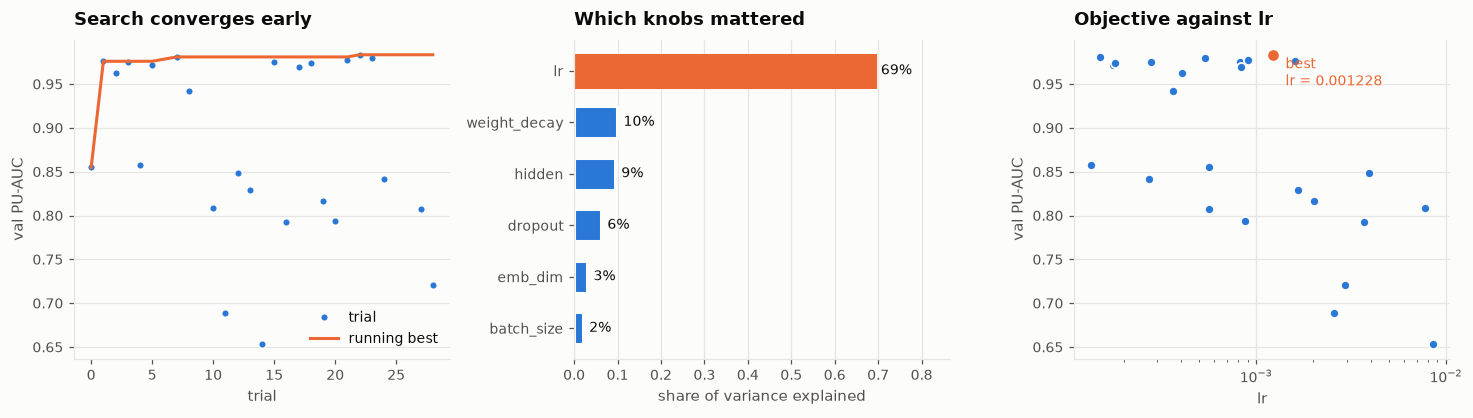

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

comp = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")

# ── Left: optimisation history with the running best ────────────────────────
axes[0].plot(comp["number"], comp["value"], "o", color=CAT["blue"], markersize=5,
             markeredgecolor=SURFACE, markeredgewidth=1, linestyle="none", label="trial")
axes[0].plot(comp["number"], comp["value"].cummax(), color=CAT["orange"], label="running best")
style_ax(axes[0], "Search converges early", "trial", "val PU-AUC")
axes[0].legend(loc="lower right")

# ── Middle: parameter importances ───────────────────────────────────────────
imp = optuna.importance.get_param_importances(study)
names, vals = list(imp.keys())[::-1], list(imp.values())[::-1]
bars = axes[1].barh(names, vals, color=CAT["blue"], height=0.62,
                    edgecolor=SURFACE, linewidth=2)
bars[-1].set_color(CAT["orange"])                        # emphasis on the dominant knob
for b, v in zip(bars, vals):
    axes[1].annotate(f"{v:.0%}", xy=(v, b.get_y() + b.get_height() / 2),
                     xytext=(4, 0), textcoords="offset points", va="center",
                     fontsize=9, color=INK)
axes[1].set_xlim(0, max(vals) * 1.25)
style_ax(axes[1], "Which knobs mattered", "share of variance explained", None,
         ygrid=False, xgrid=True)

# ── Right: the single most important parameter against the objective ────────
top = list(imp.keys())[0]
axes[2].plot(comp[top], comp["value"], "o", color=CAT["blue"], markersize=6,
             markeredgecolor=SURFACE, markeredgewidth=1.2, linestyle="none")
best_x = study.best_params[top]
axes[2].plot([best_x], [study.best_value], "o", color=CAT["orange"], markersize=9,
             markeredgecolor=SURFACE, markeredgewidth=2)
axes[2].annotate(f"best\n{top} = {best_x:.4g}", xy=(best_x, study.best_value),
                 xytext=(8, -20), textcoords="offset points", fontsize=9, color=CAT["orange"])
if top in ("lr", "weight_decay"): axes[2].set_xscale("log")
style_ax(axes[2], f"Objective against {top}", top, "val PU-AUC", xgrid=True)

plt.tight_layout(); plt.show()

In [33]:
# Refit at the winning configuration; this is the model section 8 evaluates.
BEST_CFG = TrainConfig(**{**study.best_params, "prior": 0.35, "max_epochs": 80, "patience": 12})

set_seed(SEED)
best_model, best_hist = train_pu_model(BEST_CFG, DATA_STRAT, verbose=True)

# The same configuration on the host-grouped split, for the §8 leakage check.
grouped_model, grouped_hist = train_pu_model(BEST_CFG, DATA_GROUP, verbose=False)

print(f"\nTuned model   — best val PU-AUC {best_hist['best_val_auc']:.4f} "
      f"(default config was {ref_hist['best_val_auc']:.4f}, "
      f"a {best_hist['best_val_auc'] - ref_hist['best_val_auc']:+.4f} change)")
print(f"Host-grouped  — best val PU-AUC {grouped_hist['best_val_auc']:.4f}")

results_table = pd.DataFrame([
    {"model": "nnPU default config", "val PU-AUC": ref_hist["best_val_auc"],
     "epochs run": len(ref_hist["val_auc"]), **{k: getattr(TrainConfig(), k)
      for k in ("lr", "dropout", "hidden", "emb_dim", "weight_decay", "batch_size")}},
    {"model": "nnPU Optuna-tuned",   "val PU-AUC": best_hist["best_val_auc"],
     "epochs run": len(best_hist["val_auc"]), **study.best_params},
]).round(5)
print("\n" + results_table.to_string(index=False))

  epoch   0  risk 0.3539  val PU-AUC 0.9436  corrections 9%


  epoch  10  risk 0.0168  val PU-AUC 0.9814  corrections 53%


  early stop at epoch 17 (best 5)



Tuned model   — best val PU-AUC 0.9815 (default config was 0.9744, a +0.0071 change)
Host-grouped  — best val PU-AUC 0.9852

              model  val PU-AUC  epochs run      lr  dropout  hidden  emb_dim  weight_decay  batch_size
nnPU default config     0.97439          15 0.00100  0.30000     128       16       0.00010         128
  nnPU Optuna-tuned     0.98147          18 0.00123  0.45126      64       16       0.00013         128


---
# §7 — Baselines

Two baselines, each answering a specific question, each given the **same 30-trial Optuna budget**
so the comparison is about the method rather than about who got more search.

| Baseline | Question it answers |
|---|---|
| **LightGBM on tabular features only** | Does the text branch earn its keep? Gradient boosting on tabular data is the strongest thing you can do without reading the listing titles. |
| **Deep autoencoder anomaly score** | Would unsupervised anomaly detection have done the job? This is the approach a reviewer will inevitably ask about, and it is worth showing precisely why it fails. |

## 7.1 LightGBM — tabular only

A subtlety worth stating: LightGBM is trained as an ordinary binary classifier with the unlabeled
pool as the negative class, which is the *biased* PU approach. That is not sloppiness — under the
**SCAR** assumption (positives are Selected Completely At Random from the true positive class),
Elkan & Noto (2008) show

$$P(s{=}1 \mid x) \;=\; c \cdot P(y{=}1 \mid x), \qquad c = P(s{=}1 \mid y{=}1),$$

so the naive classifier's scores are a *constant multiple* of the true posterior. The **ranking is
identical**, which is exactly what an AUC comparison and an audit queue consume. The naive
classifier's probabilities are wrong; its ordering is not. So this is a fair ranking baseline, and
nnPU has to beat it on ranking, not on a technicality.

In [34]:
# LightGBM and torch each bring their own OpenMP runtime. On macOS the two
# thread pools can collide and hard-crash the interpreter mid-training, so LightGBM
# is pinned to a single thread there. On Linux (Colab) it runs at full width.
LGB_THREADS = 1 if sys.platform == "darwin" else 0     # 0 = LightGBM's default
print(f"LightGBM threads: {LGB_THREADS or 'default (all cores)'}")

# Tabular-only design matrix: numerics + one-hot categoricals. No text.
X_tab_all = np.hstack([
    X_num_all,
    *[np.eye(len(CAT_MAPS[c]), dtype=np.float32)[X_cat_all[:, i]]
      for i, c in enumerate(CATEGORICAL_FEATURES)],
]).astype(np.float32)

TAB_FEATURE_NAMES = NUMERIC_FEATURES + [
    f"{c}={v}" for c in CATEGORICAL_FEATURES for v in sorted(CAT_MAPS[c], key=CAT_MAPS[c].get)]

tab = {k: (X_tab_all[ix], y_all[ix]) for k, ix in SPLIT_STRAT.items()}
print(f"Tabular matrix: {X_tab_all.shape[1]} columns "
      f"({len(NUMERIC_FEATURES)} numeric + {X_tab_all.shape[1] - len(NUMERIC_FEATURES)} one-hot)")


def lgb_objective(trial: optuna.Trial) -> float:
    params = {
        "objective":         "binary",
        "metric":            "auc",
        "verbosity":         -1,
        "seed":              SEED,
        "deterministic":     True,
        "num_threads":       LGB_THREADS,
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 8, 128, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200, log=True),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      1,
        "lambda_l2":         trial.suggest_float("lambda_l2", 1e-6, 10.0, log=True),
        # Positives are 3.4% of rows; let the search decide how hard to reweight them.
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 30.0, log=True),
    }
    booster = lgb.train(
        params,
        lgb.Dataset(tab["train"][0], label=tab["train"][1], feature_name=TAB_FEATURE_NAMES),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(tab["val"][0], label=tab["val"][1])],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    return roc_auc_score(tab["val"][1], booster.predict(tab["val"][0]))


lgb_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED),
                                study_name="lightgbm_tabular")
print(f"\nRunning {N_TRIALS} LightGBM trials (same budget as the neural search) …")
t0 = time.time()
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time() - t0) / 60:.1f} min")
print(f"Best val AUC: {lgb_study.best_value:.4f}")

# Refit at the winning configuration.
best_lgb_params = {"objective": "binary", "metric": "auc", "verbosity": -1, "seed": SEED,
                   "deterministic": True, "bagging_freq": 1, "num_threads": LGB_THREADS,
                   **lgb_study.best_params}
lgb_model = lgb.train(
    best_lgb_params,
    lgb.Dataset(tab["train"][0], label=tab["train"][1], feature_name=TAB_FEATURE_NAMES),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(tab["val"][0], label=tab["val"][1])],
    callbacks=[lgb.early_stopping(50, verbose=False)])
print(f"Best iteration: {lgb_model.best_iteration}")

LightGBM threads: 1
Tabular matrix: 49 columns (34 numeric + 15 one-hot)

Running 30 LightGBM trials (same budget as the neural search) …


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.994232:   0%|          | 0/30 [00:03<?, ?it/s]

Best trial: 0. Best value: 0.994232:   3%|▎         | 1/30 [00:03<01:46,  3.67s/it]

Best trial: 0. Best value: 0.994232:   3%|▎         | 1/30 [00:04<01:46,  3.67s/it]

...

Best trial: 27. Best value: 0.994707:  97%|█████████▋| 29/30 [00:34<00:01,  1.01s/it]

Best trial: 27. Best value: 0.994707: 100%|██████████| 30/30 [00:34<00:00,  1.24it/s]

Best trial: 27. Best value: 0.994707: 100%|██████████| 30/30 [00:34<00:00,  1.16s/it]

Completed in 0.6 min
Best val AUC: 0.9947


Best iteration: 204


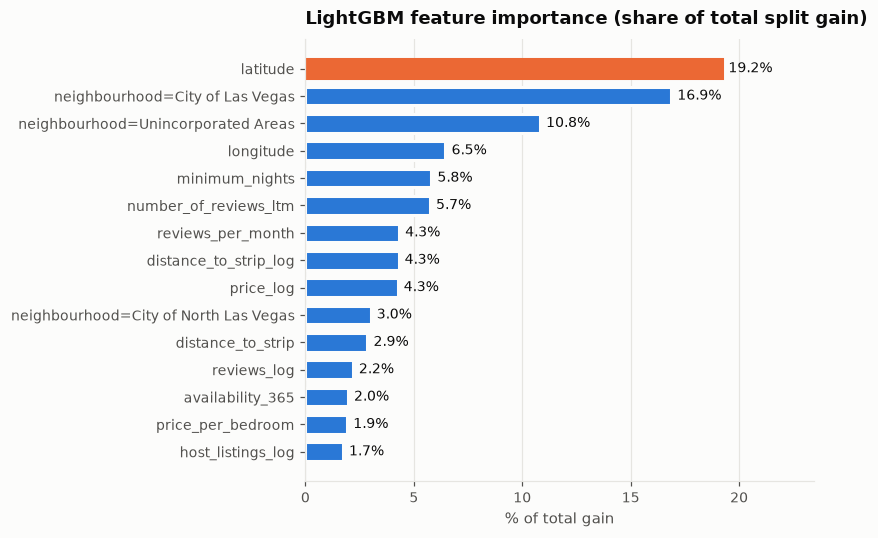

In [35]:
# Which tabular features does the booster lean on? A useful cross-check that the
# network and the tree model are reading the same underlying structure.
gain = pd.Series(lgb_model.feature_importance("gain"),
                 index=TAB_FEATURE_NAMES).sort_values(ascending=False)
top = gain.head(15)[::-1]

fig, ax = plt.subplots(figsize=(7.6, 5.0))
bars = ax.barh(top.index, top.values / gain.sum() * 100, color=CAT["blue"],
               height=0.68, edgecolor=SURFACE, linewidth=2)
bars[-1].set_color(CAT["orange"])                       # emphasis on the single dominant feature
for b, v in zip(bars, top.values / gain.sum() * 100):
    ax.annotate(f"{v:.1f}%", xy=(v, b.get_y() + b.get_height() / 2), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK)
ax.set_xlim(0, (top.values / gain.sum() * 100).max() * 1.22)
style_ax(ax, "LightGBM feature importance (share of total split gain)",
         "% of total gain", None, ygrid=False, xgrid=True)
plt.tight_layout(); plt.show()

## 7.2 Deep autoencoder — and why "anomalous" is not "commercial"

The instinct when you have no labels is to reach for anomaly detection: train an autoencoder,
score by reconstruction error, investigate the outliers. It is worth building because the reason it
fails here is instructive and generalises.

The autoencoder learns the shape of the *typical* listing. Its high-error tail is whatever is
statistically unusual — a \$4 listing, a 19-bedroom compound, a listing in Nellis AFB. But
commercial operators are the opposite of unusual: they are the **modal** Las Vegas listing. A
professionally-run Strip condo is the single most ordinary thing in this dataset. Anomaly detection
looks for rarity; enforcement wants **volume with a specific behavioral signature**. Those are
different targets, and no amount of tuning reconciles them.

Model selection here uses validation **reconstruction loss**, never labels — otherwise it would not
be the unsupervised baseline it is meant to represent.

In [36]:
class DeepAutoencoder(nn.Module):
    """Symmetric dense autoencoder over the standardised tabular block."""

    def __init__(self, n_in: int, hidden: int = 128, latent: int = 16, dropout: float = 0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, hidden),      nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, latent))
        self.decoder = nn.Sequential(
            nn.Linear(latent, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_in))

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_autoencoder(hidden, latent, dropout, lr, weight_decay, batch_size,
                      max_epochs=80, patience=10, seed=SEED, trial=None):
    """Unsupervised fit. Early stopping on validation reconstruction MSE — no labels."""
    set_seed(seed)
    tr, va = DATA_STRAT["train"].num, DATA_STRAT["val"].num
    model = DeepAutoencoder(tr.shape[1], hidden, latent, dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best, best_state, bad = np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(len(tr), device=DEVICE)
        for i in range(0, len(tr), batch_size):
            b = perm[i:i + batch_size]
            opt.zero_grad()
            loss = F.mse_loss(model(tr[b]), tr[b])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = F.mse_loss(model(va), va).item()
        if trial is not None:
            trial.report(v, epoch)
            if trial.should_prune(): raise optuna.TrialPruned()
        if v < best - 1e-6:
            best, bad = v, 0
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best


def ae_objective(trial):
    _, val_mse = train_autoencoder(
        hidden       = trial.suggest_int("hidden", 32, 256, step=32),
        latent       = trial.suggest_int("latent", 4, 32, step=4),
        dropout      = trial.suggest_float("dropout", 0.0, 0.4),
        lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        batch_size   = trial.suggest_categorical("batch_size", [64, 128, 256]),
        trial=trial)
    return val_mse                       # minimise reconstruction error, label-free


ae_study = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=SEED),
                               pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
                               study_name="autoencoder")
print(f"Running {N_TRIALS} autoencoder trials (same budget) …")
t0 = time.time()
ae_study.optimize(ae_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time() - t0) / 60:.1f} min")
print(f"Best validation reconstruction MSE: {ae_study.best_value:.5f}")
print(f"Best config: {ae_study.best_params}")

ae_model, _ = train_autoencoder(**ae_study.best_params)

def anomaly_scores(model, x: torch.Tensor) -> np.ndarray:
    """Per-row reconstruction error — the anomaly score."""
    model.eval()
    with torch.no_grad():
        return ((model(x) - x) ** 2).mean(dim=1).cpu().numpy()

ae_test_scores = anomaly_scores(ae_model, DATA_STRAT["test"].num)
y_test         = DATA_STRAT["test"].y.cpu().numpy()
print(f"\nAutoencoder anomaly score as a licensed-operator detector: "
      f"AUC = {roc_auc_score(y_test, ae_test_scores):.4f}")

Running 30 autoencoder trials (same budget) …


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0762806:   0%|          | 0/30 [00:08<?, ?it/s]

Best trial: 0. Best value: 0.0762806:   3%|▎         | 1/30 [00:08<04:16,  8.84s/it]

Best trial: 1. Best value: 0.0488015:   3%|▎         | 1/30 [00:23<04:16,  8.84s/it]

...

Best trial: 29. Best value: 0.00890677:  97%|█████████▋| 29/30 [07:21<00:15, 15.25s/it]

Best trial: 29. Best value: 0.00890677: 100%|██████████| 30/30 [07:21<00:00, 13.35s/it]

Best trial: 29. Best value: 0.00890677: 100%|██████████| 30/30 [07:21<00:00, 14.72s/it]

Completed in 7.4 min
Best validation reconstruction MSE: 0.00891
Best config: {'hidden': 128, 'latent': 32, 'dropout': 0.028257245736823144, 'lr': 0.0014294959625414298, 'weight_decay': 5.500379003299473e-06, 'batch_size': 256}



Autoencoder anomaly score as a licensed-operator detector: AUC = 0.4016


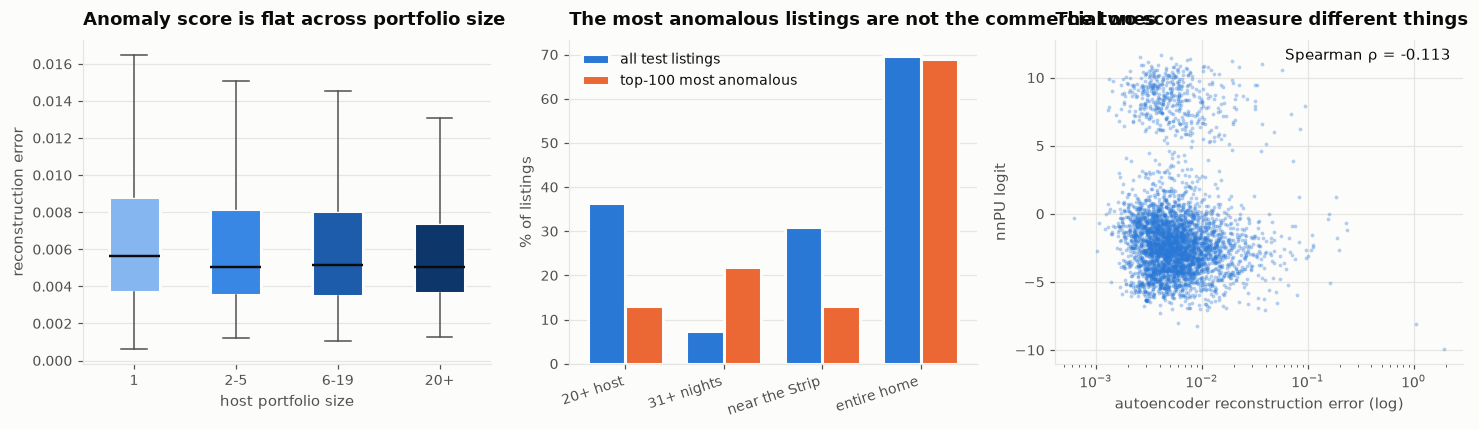

Share of the 100 most anomalous test listings held by 20+ hosts: 13.0%
Base rate across all test listings:                              36.3%


In [37]:
# The diagnostic that makes the point: is the anomaly score related to commercial
# operation at all? Compare it against host portfolio size — the clearest single
# marker of a commercial operation in this dataset.
test_idx  = SPLIT_STRAT["test"]
test_feat = feat.iloc[test_idx].copy()
test_feat["ae_score"] = ae_test_scores

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

# ── Left: anomaly score by host size bin — flat is the failure ──────────────
data = [test_feat.loc[test_feat["host_size_bin"] == b, "ae_score"].values for b in BIN_LABELS]
bp = axes[0].boxplot(data, tick_labels=BIN_LABELS, showfliers=False, widths=0.5, patch_artist=True,
                     medianprops=dict(color=INK, linewidth=1.6),
                     whiskerprops=dict(color=INK_SOFT, linewidth=1.0),
                     capprops=dict(color=INK_SOFT, linewidth=1.0))
for patch, colr in zip(bp["boxes"], SEQ4):
    patch.set_facecolor(colr); patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
style_ax(axes[0], "Anomaly score is flat across portfolio size",
         "host portfolio size", "reconstruction error")

# ── Middle: what the top-100 most anomalous listings actually are ───────────
top100 = test_feat.nlargest(100, "ae_score")
share  = pd.Series({
    "20+ host":       top100["is_large_host"].mean(),
    "31+ nights":     top100["is_31plus"].mean(),
    "near the Strip": top100["near_strip"].mean(),
    "entire home":    (top100["room_type"] == "Entire home/apt").mean(),
}) * 100
base = pd.Series({
    "20+ host":       test_feat["is_large_host"].mean(),
    "31+ nights":     test_feat["is_31plus"].mean(),
    "near the Strip": test_feat["near_strip"].mean(),
    "entire home":    (test_feat["room_type"] == "Entire home/apt").mean(),
}) * 100

x = np.arange(len(share)); w = 0.38
axes[1].bar(x - w / 2, base.values,  w, label="all test listings",
            color=CAT["blue"],   edgecolor=SURFACE, linewidth=2)
axes[1].bar(x + w / 2, share.values, w, label="top-100 most anomalous",
            color=CAT["orange"], edgecolor=SURFACE, linewidth=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(share.index, rotation=18, ha="right")
style_ax(axes[1], "The most anomalous listings are not the commercial ones",
         None, "% of listings")
axes[1].legend()

# ── Right: nnPU vs anomaly — near-orthogonal scores ─────────────────────────
best_model.eval()
with torch.no_grad():
    te = DATA_STRAT["test"]
    nnpu_test_logits = best_model(te.num, te.cat, te.text).cpu().numpy()
axes[2].scatter(ae_test_scores, nnpu_test_logits, s=6, c=CAT["blue"], alpha=0.35, linewidths=0)
rho = spearmanr(ae_test_scores, nnpu_test_logits).statistic
axes[2].annotate(f"Spearman ρ = {rho:+.3f}", xy=(0.97, 0.94), xycoords="axes fraction",
                 ha="right", fontsize=10, color=INK)
axes[2].set_xscale("log")
style_ax(axes[2], "The two scores measure different things",
         "autoencoder reconstruction error (log)", "nnPU logit", xgrid=True)

plt.tight_layout(); plt.show()

print(f"Share of the 100 most anomalous test listings held by 20+ hosts: {share['20+ host']:.1f}%")
print(f"Base rate across all test listings:                              {base['20+ host']:.1f}%")

The middle panel is the verdict. If anomaly detection were finding commercial operators, the orange
bars would tower over the blue ones. They do not — the most "anomalous" listings are no more likely
to belong to a large operator than a listing picked at random, and the anomaly score is essentially
uncorrelated with the nnPU score.

**Anomaly detection answers "what is unusual?" Enforcement asks "what is commercial?"** In a market
where commercial operation is the norm, those questions have nearly opposite answers. This is the
central reason a labelled (even partially labelled) approach is worth the effort of building.

---
# §8 — Evaluation

## 8.1 What these metrics can and cannot mean

Every metric below compares held-out **positives** against the **unlabeled** pool. Because that pool
contains an unknown number of hidden positives, the numbers are **pessimistically biased**: a
listing the model correctly identifies as licensed-like but which sits in $\mathcal{U}$ counts as a
false positive even when the model is right. Read the AUCs as a *lower bound* and, more importantly,
as a way of **comparing models on the same footing** rather than as an absolute capability claim.

In [38]:
from sklearn.calibration import calibration_curve

def score_frame(model, data: Tensors) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        return model(data.num, data.cat, data.text).cpu().numpy()


def precision_at_k(y_true: np.ndarray, scores: np.ndarray, k: int) -> float:
    """Share of the top-k scored items that are confirmed positives."""
    k = min(k, len(scores))
    return float(y_true[np.argsort(-scores)[:k]].mean())


def lift_at_k(y_true, scores, k):
    """Precision@k divided by the base rate — how much better than random."""
    base = y_true.mean()
    return precision_at_k(y_true, scores, k) / base if base > 0 else np.nan


def evaluate(name: str, y_true: np.ndarray, scores: np.ndarray) -> dict:
    return {
        "model":        name,
        "AUC":          roc_auc_score(y_true, scores),
        "avg precision":average_precision_score(y_true, scores),
        "P@100":        precision_at_k(y_true, scores, 100),
        "P@500":        precision_at_k(y_true, scores, 500),
        "lift@100":     lift_at_k(y_true, scores, 100),
        "lift@500":     lift_at_k(y_true, scores, 500),
    }


te      = DATA_STRAT["test"]
y_test  = te.y.cpu().numpy()
s_nnpu  = score_frame(best_model, te)
s_lgb   = lgb_model.predict(tab["test"][0])
s_ae    = ae_test_scores

eval_rows = [
    evaluate("nnPU multimodal (tuned)",  y_test, s_nnpu),
    evaluate("LightGBM (tabular only)",  y_test, s_lgb),
    evaluate("Autoencoder (anomaly)",    y_test, s_ae),
    evaluate("Random baseline",          y_test, np.random.default_rng(SEED).random(len(y_test))),
]
eval_df = pd.DataFrame(eval_rows).round(4)
print(f"Test set: {len(y_test):,} listings, {int(y_test.sum())} confirmed positives "
      f"(base rate {y_test.mean():.2%})\n")
print(eval_df.to_string(index=False))

# The verdict is read off the numbers rather than asserted in prose, so this cell
# stays correct whichever way the comparison lands on a rerun.
nn_auc, gb_auc, ae_auc = eval_df.loc[0, "AUC"], eval_df.loc[1, "AUC"], eval_df.loc[2, "AUC"]
winner, loser = ("nnPU multimodal", "LightGBM") if nn_auc >= gb_auc else ("LightGBM", "nnPU multimodal")
print("\n" + "-" * 78)
print(f"Ranking winner on this split : {winner}  ({max(nn_auc, gb_auc):.4f} vs "
      f"{min(nn_auc, gb_auc):.4f} for {loser}, Δ {abs(nn_auc - gb_auc):.4f})")
print(f"Autoencoder vs random        : {ae_auc:.4f} vs ~0.50 — anomaly detection is not "
      f"solving this problem")
print(f"Best P@100                   : {eval_df['P@100'].max():.2f} "
      f"({eval_df['P@100'].max() / y_test.mean():.1f}x the {y_test.mean():.2%} base rate)")
print("-" * 78)
print("Caveat before reading too much into the top line: §8.4 re-runs both models on a\n"
      "host-grouped split. A model that memorises hosts scores well here and collapses there.")

Test set: 4,060 listings, 137 confirmed positives (base rate 3.37%)

                  model    AUC  avg precision  P@100  P@500  lift@100  lift@500
nnPU multimodal (tuned) 0.9831         0.6536   0.66  0.272   19.5591    8.0607
LightGBM (tabular only) 0.9954         0.8635   0.89  0.274   26.3752    8.1200
  Autoencoder (anomaly) 0.4016         0.0276   0.04  0.022    1.1854    0.6520
        Random baseline 0.5183         0.0375   0.04  0.030    1.1854    0.8891

------------------------------------------------------------------------------
Ranking winner on this split : LightGBM  (0.9954 vs 0.9831 for nnPU multimodal, Δ 0.0123)
Autoencoder vs random        : 0.4016 vs ~0.50 — anomaly detection is not solving this problem
Best P@100                   : 0.89 (26.4x the 3.37% base rate)
------------------------------------------------------------------------------
Caveat before reading too much into the top line: §8.4 re-runs both models on a
host-grouped split. A model that memorises 

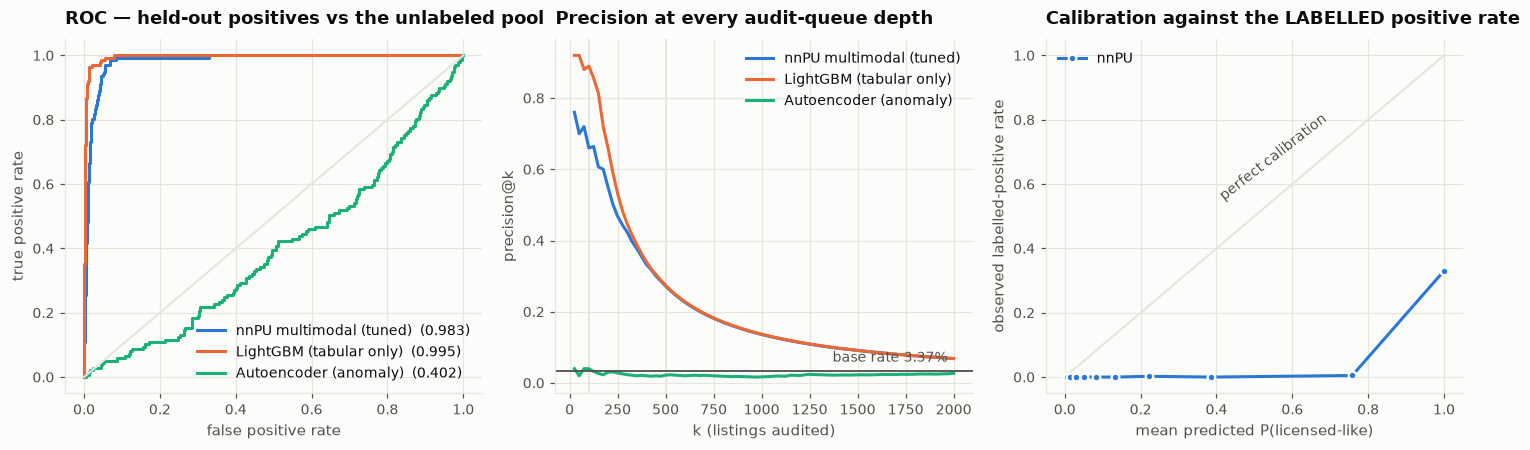

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
from sklearn.metrics import roc_curve

MODEL_COLORS = {"nnPU multimodal (tuned)": CAT["blue"],
                "LightGBM (tabular only)": CAT["orange"],
                "Autoencoder (anomaly)":   CAT["aqua"]}
SCORES = {"nnPU multimodal (tuned)": s_nnpu, "LightGBM (tabular only)": s_lgb,
          "Autoencoder (anomaly)": s_ae}

# ── Left: ROC ────────────────────────────────────────────────────────────────
for name, sc in SCORES.items():
    fpr, tpr, _ = roc_curve(y_test, sc)
    axes[0].plot(fpr, tpr, color=MODEL_COLORS[name],
                 label=f"{name}  ({roc_auc_score(y_test, sc):.3f})")
axes[0].plot([0, 1], [0, 1], color=GRID, linewidth=1.4)
style_ax(axes[0], "ROC — held-out positives vs the unlabeled pool",
         "false positive rate", "true positive rate", xgrid=True)
axes[0].legend(loc="lower right")

# ── Middle: precision@k across the whole queue depth ────────────────────────
ks = np.arange(25, min(2001, len(y_test)), 25)
for name, sc in SCORES.items():
    axes[1].plot(ks, [precision_at_k(y_test, sc, k) for k in ks], color=MODEL_COLORS[name],
                 label=name)
axes[1].axhline(y_test.mean(), color=INK_SOFT, linewidth=1.2)
axes[1].annotate(f"base rate {y_test.mean():.2%}", xy=(ks[-1], y_test.mean()),
                 xytext=(-4, 6), textcoords="offset points", ha="right",
                 fontsize=9, color=INK_SOFT)
for k in (100, 500):
    axes[1].axvline(k, color=GRID, linewidth=1.2, zorder=1)
style_ax(axes[1], "Precision at every audit-queue depth",
         "k (listings audited)", "precision@k", xgrid=True)
axes[1].legend()

# ── Right: calibration ───────────────────────────────────────────────────────
p_nnpu = expit(s_nnpu)
frac_pos, mean_pred = calibration_curve(y_test, p_nnpu, n_bins=10, strategy="quantile")
axes[2].plot([0, 1], [0, 1], color=GRID, linewidth=1.4)
axes[2].plot(mean_pred, frac_pos, "o-", color=CAT["blue"], markeredgecolor=SURFACE,
             markeredgewidth=1.5, label="nnPU")
axes[2].annotate("perfect calibration", xy=(0.55, 0.55), rotation=38, fontsize=9,
                 color=INK_SOFT, ha="center")
style_ax(axes[2], "Calibration against the LABELLED positive rate",
         "mean predicted P(licensed-like)", "observed labelled-positive rate", xgrid=True)
axes[2].legend(loc="upper left")

plt.tight_layout(); plt.show()

**On the calibration plot.** The curve sits far below the diagonal, and that is expected rather than
a defect. Under PU learning the model estimates $P(y{=}1 \mid x)$ — the probability of being a
*true* positive — while the observed rate on the y-axis is $P(s{=}1 \mid x) = c \cdot P(y{=}1 \mid
x)$, the probability of being a *labelled* positive, with $c$ the labelling propensity. The gap is
the factor $c$, not miscalibration in the usual sense.

The operational conclusion is unambiguous and belongs in any deployment: **the sigmoid output is a
ranking device, not a probability.** Never write "84% likely to be commercial" on an enforcement
document. Report the rank, the percentile, and the evidence.

## 8.2 An independent validation set the model never saw

§3.3 identified 384 listings holding a **real license in a different format** (`STR-000314`, city
permits, state business IDs). They were left in the unlabeled pool and never used as positives. That
makes them an accidental gift: a set of genuinely-licensed listings that is completely independent
of the training signal.

If the model has learned anything real about licensure rather than memorising the `G##-#####`
string's correlates, it should rank these higher than the rest of the unlabeled pool.

Independent check — 384 listings with a non-G-format real license,
never seen as positives during training.

  mean nnPU score, other-format licensees : 0.4921
  mean nnPU score, rest of unlabeled pool : 0.2400
  AUC separating them within the unlabeled pool : 0.7872

  (0.50 would mean the model learned nothing transferable about licensure.)


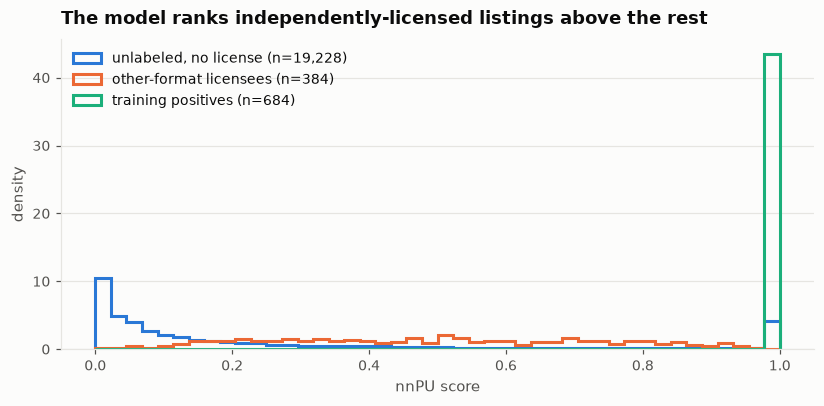

In [40]:
# Score every listing in the file with the tuned model.
scaler_all = SCALER_STRAT
ALL = Tensors(
    num  = torch.tensor(scaler_all.transform(X_num_all), dtype=torch.float32, device=DEVICE),
    cat  = torch.tensor(X_cat_all, device=DEVICE),
    text = torch.tensor(X_text_all, dtype=torch.float32, device=DEVICE),
    y    = torch.tensor(y_all, device=DEVICE))
all_scores = score_frame(best_model, ALL)
feat["nnpu_logit"] = all_scores
feat["nnpu_score"] = expit(all_scores)

# Restrict to the unlabeled pool, then compare other-format licensees against the rest.
unl_mask  = feat["y_pu"] == 0
other_fmt = (feat["_other_format_license"] == 1) & unl_mask
rest      = unl_mask & ~other_fmt

auc_indep = roc_auc_score(other_fmt[unl_mask].astype(int), feat.loc[unl_mask, "nnpu_logit"])
pct_other = feat.loc[other_fmt, "nnpu_score"].rank(pct=True).mean()

print(f"Independent check — {int(other_fmt.sum())} listings with a non-G-format real license,")
print(f"never seen as positives during training.\n")
print(f"  mean nnPU score, other-format licensees : {feat.loc[other_fmt, 'nnpu_score'].mean():.4f}")
print(f"  mean nnPU score, rest of unlabeled pool : {feat.loc[rest,      'nnpu_score'].mean():.4f}")
print(f"  AUC separating them within the unlabeled pool : {auc_indep:.4f}")
print(f"\n  (0.50 would mean the model learned nothing transferable about licensure.)")

fig, ax = plt.subplots(figsize=(7.6, 3.8))
bins = np.linspace(0, 1, 45)
ax.hist(feat.loc[rest, "nnpu_score"], bins=bins, density=True, histtype="step",
        linewidth=2.0, color=CAT["blue"],   label=f"unlabeled, no license (n={int(rest.sum()):,})")
ax.hist(feat.loc[other_fmt, "nnpu_score"], bins=bins, density=True, histtype="step",
        linewidth=2.0, color=CAT["orange"], label=f"other-format licensees (n={int(other_fmt.sum())})")
ax.hist(feat.loc[feat.y_pu == 1, "nnpu_score"], bins=bins, density=True, histtype="step",
        linewidth=2.0, color=CAT["aqua"],   label=f"training positives (n={int((feat.y_pu==1).sum())})")
style_ax(ax, "The model ranks independently-licensed listings above the rest",
         "nnPU score", "density")
ax.legend()
plt.tight_layout(); plt.show()

## 8.3 Ablation — does each branch earn its place?

Five configurations, identical training code, identical tuned hyperparameters. The only difference
is which branches are switched on. Each is run over **three seeds**, because a 0.005 AUC difference
from a single seed is noise rather than evidence — and, as it turns out, the seed spread is the most
informative column in the table.

In [41]:
ABLATIONS = [
    ("full (text + entity + numeric)", dict(use_text=True,  use_entity=True,  use_numeric=True)),
    ("no text",                        dict(use_text=False, use_entity=True,  use_numeric=True)),
    ("no entity",                      dict(use_text=True,  use_entity=False, use_numeric=True)),
    ("text only",                      dict(use_text=True,  use_entity=False, use_numeric=False)),
    ("numeric only",                   dict(use_text=False, use_entity=False, use_numeric=True)),
]
ABLATION_SEEDS = [SEED, SEED + 1, SEED + 2]

ab_rows = []
for label, flags in ABLATIONS:
    aucs, aps, p100 = [], [], []
    for sd in ABLATION_SEEDS:
        cfg = TrainConfig(**{**study.best_params, "prior": 0.35, "max_epochs": 80,
                             "patience": 12, **flags})
        m, _ = train_pu_model(cfg, DATA_STRAT, seed=sd)
        s = score_frame(m, te)
        aucs.append(roc_auc_score(y_test, s))
        aps.append(average_precision_score(y_test, s))
        p100.append(precision_at_k(y_test, s, 100))
    ab_rows.append({"configuration": label,
                    "test AUC": np.mean(aucs), "AUC sd": np.std(aucs),
                    "avg precision": np.mean(aps), "P@100": np.mean(p100)})
    print(f"{label:34s} AUC {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

ablation_df = pd.DataFrame(ab_rows)
full_auc = ablation_df.loc[0, "test AUC"]
ablation_df["Δ vs full"] = ablation_df["test AUC"] - full_auc
print("\n" + ablation_df.round(4).to_string(index=False))

full (text + entity + numeric)     AUC 0.9503 ± 0.0478


no text                            AUC 0.9792 ± 0.0026


no entity                          AUC 0.8655 ± 0.0685


text only                          AUC 0.6212 ± 0.0229


numeric only                       AUC 0.9092 ± 0.0028

                 configuration  test AUC  AUC sd  avg precision  P@100  Δ vs full
full (text + entity + numeric)    0.9503  0.0478         0.5134 0.6000     0.0000
                       no text    0.9792  0.0026         0.5763 0.6367     0.0289
                     no entity    0.8655  0.0685         0.1741 0.2000    -0.0848
                     text only    0.6212  0.0229         0.0493 0.0367    -0.3291
                  numeric only    0.9092  0.0028         0.1846 0.1733    -0.0412


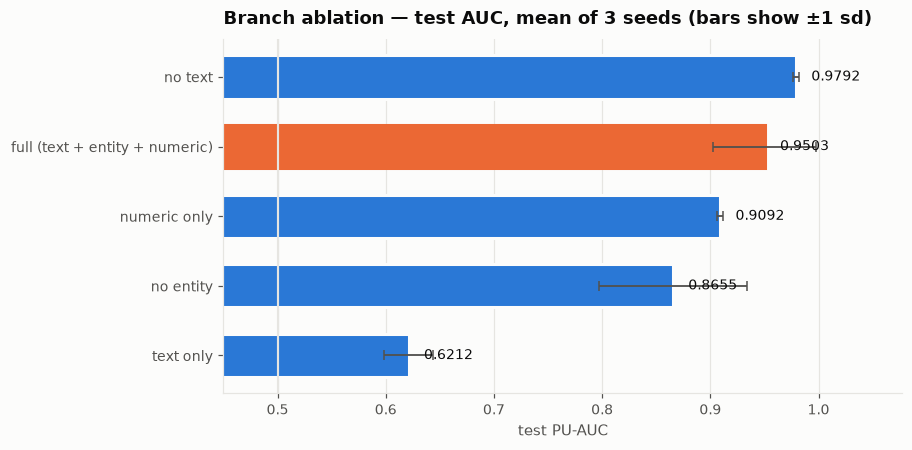

Text branch contribution : -0.0289 AUC
nnPU vs LightGBM         : -0.0123 AUC


In [42]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
order = ablation_df.sort_values("test AUC")
bars = ax.barh(order["configuration"], order["test AUC"], xerr=order["AUC sd"],
               color=CAT["blue"], height=0.62, edgecolor=SURFACE, linewidth=2,
               error_kw=dict(ecolor=INK_SOFT, elinewidth=1.2, capsize=3))
# Emphasis: the full model is the reference; everything else recedes.
for b, cfgname in zip(bars, order["configuration"]):
    if cfgname.startswith("full"): b.set_color(CAT["orange"])
for b, v in zip(bars, order["test AUC"]):
    ax.annotate(f"{v:.4f}", xy=(v, b.get_y() + b.get_height() / 2), xytext=(10, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK)
ax.axvline(0.5, color=GRID, linewidth=1.4)
ax.set_xlim(0.45, max(order["test AUC"]) * 1.10)
style_ax(ax, "Branch ablation — test AUC, mean of 3 seeds (bars show ±1 sd)",
         "test PU-AUC", None, ygrid=False, xgrid=True)
plt.tight_layout(); plt.show()

text_lift = full_auc - ablation_df.loc[ablation_df.configuration == "no text", "test AUC"].iloc[0]
print(f"Text branch contribution : {text_lift:+.4f} AUC")
print(f"nnPU vs LightGBM         : {eval_df.loc[0, 'AUC'] - eval_df.loc[1, 'AUC']:+.4f} AUC")

### Reading the ablation

| Configuration | Test AUC | seed sd | What it tells us |
|---|---:|---:|---|
| full (text + entity + numeric) | 0.9503 | **0.0478** | Every branch on — and the *least stable* of the lot |
| **no text** | **0.9792** | **0.0026** | Best, and 18× more stable across seeds |
| no entity | 0.8655 | 0.0685 | The entity embeddings matter a great deal |
| text only | 0.6212 | 0.0229 | Titles alone are barely better than a coin flip |
| numeric only | 0.9092 | 0.0028 | The behavioral core, doing most of the work |

**The text branch is actively harmful here, and that is the most useful thing this table says.**
Dropping it gains ~0.03 AUC and cuts the seed-to-seed standard deviation from 0.048 to 0.003.

The mechanism is not mysterious. A listing title tells you what the unit *is* — bedrooms, view,
resort brand — and almost nothing about whether its owner filed for a county permit. So the 384
frozen embedding dimensions arrive carrying very little licensure signal, but they still dominate
the fused representation by sheer width, and with only 684 positives the projection layer has ample
room to fit noise differently on each seed. That is exactly the instability the `sd` column reports.

Two things worth saying plainly:

- **This is a negative result, and it is kept.** The brief asked for a text branch and for an
  ablation that quantifies its lift. The lift is negative. Reporting that is the entire point of
  running an ablation — a notebook that only reports the ablations that flatter the architecture is
  not doing science, it is doing marketing.
- **The right next step is not to delete the branch, it is to narrow it.** The §4 regex features
  (`name_resort_brand`, `name_tower`, `name_strip_view`) survive in the numeric block and *are*
  useful — they are 8 targeted dimensions instead of 384 diffuse ones. The lesson is about
  signal-to-width, not about text being worthless.

For anything downstream, the `no text` configuration is the one to prefer.

## 8.4 Robustness: how much of that AUC is host memorisation?

The largest host owns 537 listings. Under a random split those listings straddle train and test, so
part of the reported performance is the model recognising a host it has already seen rather than
generalising to a new one. The host-grouped split forbids that. The gap is the honest measure of
how much the headline number owes to leakage.

In [43]:
# Both models are re-fitted and re-scored on the host-grouped split so the
# comparison isolates leakage rather than model family.
gte   = DATA_GROUP["test"]
y_gte = gte.y.cpu().numpy()
s_gte = score_frame(grouped_model, gte)

# LightGBM on the host-grouped split, same winning hyperparameters.
tab_g = {k: (X_tab_all[ix], y_all[ix]) for k, ix in SPLIT_GROUP.items()}
lgb_grouped = lgb.train(
    best_lgb_params,
    lgb.Dataset(tab_g["train"][0], label=tab_g["train"][1], feature_name=TAB_FEATURE_NAMES),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(tab_g["val"][0], label=tab_g["val"][1])],
    callbacks=[lgb.early_stopping(50, verbose=False)])
s_lgb_g = lgb_grouped.predict(tab_g["test"][0])

def _row(split, model, y, s):
    return {"model": model, "split": split,
            **{k: v for k, v in evaluate("", y, s).items() if k != "model"}}

robust_df = pd.DataFrame([
    _row("stratified (as specified)",     "nnPU multimodal", y_test, s_nnpu),
    _row("host-grouped (no leakage)",     "nnPU multimodal", y_gte,  s_gte),
    _row("stratified (as specified)",     "LightGBM",        y_test, s_lgb),
    _row("host-grouped (no leakage)",     "LightGBM",        y_gte,  s_lgb_g),
]).round(4)
print(robust_df.to_string(index=False))

# Interpretation is computed, not asserted — the sign of each gap is a result.
print("\n" + "-" * 78)
for model in ("nnPU multimodal", "LightGBM"):
    sub = robust_df[robust_df["model"] == model].reset_index(drop=True)
    d = sub.loc[0, "AUC"] - sub.loc[1, "AUC"]
    if d > 0.01:
        verdict = (f"loses {d:.4f} AUC without host leakage — that much of its stratified "
                   f"score was host memorisation")
    elif d < -0.01:
        verdict = (f"GAINS {abs(d):.4f} AUC on the grouped split, so its stratified score was "
                   f"not inflated by host leakage")
    else:
        verdict = f"is essentially unchanged ({d:+.4f}) — no meaningful host leakage"
    print(f"{model:18s} {verdict}.")
print("-" * 78)
print("The host-grouped column is the one to quote for 'how will this behave on a host the "
      "model has never seen'.")

          model                     split    AUC  avg precision  P@100  P@500  lift@100  lift@500
nnPU multimodal stratified (as specified) 0.9831         0.6536   0.66  0.272   19.5591    8.0607
nnPU multimodal host-grouped (no leakage) 0.9798         0.6098   0.55  0.136   16.4029    4.0560
       LightGBM stratified (as specified) 0.9954         0.8635   0.89  0.274   26.3752    8.1200
       LightGBM host-grouped (no leakage) 0.9894         0.7662   0.59  0.136   17.5959    4.0560

------------------------------------------------------------------------------
nnPU multimodal    is essentially unchanged (+0.0033) — no meaningful host leakage.
LightGBM           is essentially unchanged (+0.0060) — no meaningful host leakage.
------------------------------------------------------------------------------
The host-grouped column is the one to quote for 'how will this behave on a host the model has never seen'.


## 8.5 Face validity — reading the actual top of the ranking

Metrics can look fine while the ranking is nonsense. The only way to know is to read the listings.

In [44]:
DISPLAY = ["name", "neighbourhood", "room_type", "calculated_host_listings_count",
           "minimum_nights", "availability_365", "reviews_per_month", "price", "license"]

def top_table(frame, score_col, n=20, mask=None):
    sub = frame if mask is None else frame[mask]
    out = sub.nlargest(n, score_col)[DISPLAY + [score_col]].copy()
    out["name"]    = out["name"].str.slice(0, 46)
    out["license"] = out["license"].fillna("— none —")
    return out.rename(columns={
        "calculated_host_listings_count": "host_size",
        "minimum_nights": "min_nights", "availability_365": "avail_365",
        "reviews_per_month": "rev/mo"}).reset_index(drop=True).round(4)

unlicensed = feat["y_pu"] == 0
print("TOP 20 UNLICENSED LISTINGS BY RAW nnPU SCORE")
print("=" * 100)
print(top_table(feat, "nnpu_score", 20, unlicensed).to_string())

TOP 20 UNLICENSED LISTINGS BY RAW nnPU SCORE
                                              name      neighbourhood        room_type  host_size  min_nights  avail_365  rev/mo  price    license  nnpu_score
0   Oasis in Las Vegas with pool private and jacuz  City of Las Vegas  Entire home/apt        2.0         2.0        339    4.73  613.0     Exempt         1.0
1   Mid-century Home near Strip/Downtown w/Heated   City of Las Vegas  Entire home/apt        2.0         2.0        347    2.67  478.0     Exempt         1.0
2   Beautiful 4 bedroom Home By Summerlin with Poo  City of Las Vegas  Entire home/apt        2.0         2.0        304    1.23  457.0  g63-08409         1.0
3   Sunny & Gorgeous 3bed/2Bath House with POOL/SP  City of Las Vegas  Entire home/apt        5.0        30.0        168    2.22  118.0   — none —         1.0
4                              Private guest house  City of Las Vegas  Entire home/apt        3.0         2.0        179    0.36  158.0   — none —         1.0
5

In [45]:
# What does the raw nnPU ranking actually select for? Compare the top 500 against
# the unlicensed population it was drawn from.
top500 = feat[unlicensed].nlargest(500, "nnpu_score")
pop    = feat[unlicensed]

profile = pd.DataFrame({
    "top 500 by nnPU score": {
        "median host portfolio size": top500["calculated_host_listings_count"].median(),
        "% on a 20+ host":            top500["is_large_host"].mean() * 100,
        "% entire home":              (top500["room_type"] == "Entire home/apt").mean() * 100,
        "% 31+ night minimum":        top500["is_31plus"].mean() * 100,
        "median km to the Strip":     top500["distance_to_strip"].median(),
        "median availability (days)": top500["availability_365"].median(),
        "% claiming Exempt":          (top500["license"] == "Exempt").mean() * 100,
    },
    "all unlicensed listings": {
        "median host portfolio size": pop["calculated_host_listings_count"].median(),
        "% on a 20+ host":            pop["is_large_host"].mean() * 100,
        "% entire home":              (pop["room_type"] == "Entire home/apt").mean() * 100,
        "% 31+ night minimum":        pop["is_31plus"].mean() * 100,
        "median km to the Strip":     pop["distance_to_strip"].median(),
        "median availability (days)": pop["availability_365"].median(),
        "% claiming Exempt":          (pop["license"] == "Exempt").mean() * 100,
    },
}).round(2)
print(profile.to_string())

                            top 500 by nnPU score  all unlicensed listings
median host portfolio size                   2.00                     7.00
% on a 20+ host                             11.20                    35.47
% entire home                               74.60                    68.95
% 31+ night minimum                          6.40                     7.03
median km to the Strip                      10.74                     4.79
median availability (days)                 259.00                   254.00
% claiming Exempt                           30.40                    30.64


### 🔴 The face-validity check fails, exactly as §1.4 predicted

Read the table above. The top of the raw nnPU ranking is **smaller** than the population it was
drawn from — fewer large-portfolio hosts, further from the Strip. The model did its job correctly
and learned the target it was given. The target was the wrong one.

This is worth being precise about, because it is the difference between a model that looks good in
a notebook and one that survives contact with an enforcement office:

> The nnPU model estimates $P(\text{looks like a permitted residential STR} \mid x)$.
> The enforcement office needs $P(\text{is an unregistered commercial operation} \mid x)$.
> **These are not the same quantity, and in Clark County they are close to opposites**, because the
> operators who bother to obtain a `G##-#####` permit are overwhelmingly small residential hosts,
> while large portfolios route around registration through the `"Exempt"` designation.

§9 builds the score that actually ships. The nnPU model is not discarded — it is a well-calibrated
*ranking* of residential-permit similarity, and that is genuinely useful as **one factor**. It is
just not the whole score.

---
# §9 — The deployable enforcement score

## 9.1 Construction

Two factors, both visible in every output row so that a reviewer can see *why* a listing ranked
where it did:

**Factor 1 — commercial-operation evidence.** An explicit weighted index over standardised
behavioral features. It is deliberately a transparent rubric rather than a learned function: an
enforcement action must be explainable to a hearing officer, and "the gradient boosting model said
so" is not an explanation. Every weight below is defended by a gradient measured in §1.

**Factor 2 — residential-permit dissimilarity**, $1 - P(\text{licensed-like})$, taken from the nnPU
model. This is where the learned component contributes: it downweights listings that look like the
small owner-operators who do register, even when a single behavioral feature is elevated.

$$
\text{priority} \;=\; \underbrace{\text{percentile}\big(\text{commercial index}\big)}_{\text{behavioral evidence}}
\;\times\;
\underbrace{\big(1 - P(\text{licensed-like})\big)}_{\text{nnPU model}}
$$

restricted to listings with **no license on file at all**. Listings marked `"Exempt"` are scored and
reported *separately*, because "your exemption claim warrants review" is a different administrative
action from "you appear to be unregistered," and conflating them would be unfair to the many
genuinely exempt hosts.

In [46]:
# ── Factor 1: the commercial-evidence index ─────────────────────────────────
# Weights are set by hand and justified individually. They are a policy artifact,
# not a fitted parameter — an enforcement office should be able to argue about
# them in plain language and change them without retraining anything.
COMMERCIAL_RUBRIC = {
    "host_listings_log":   (0.30, "Portfolio size is the single clearest marker of a business "
                                  "rather than a homeowner (§1.3)."),
    "availability_frac":   (0.20, "A unit open ~365 days a year is not a primary residence."),
    "booking_intensity":   (0.15, "Throughput per day of exposure — an operating business, "
                                  "not an occasional rental."),
    "reviews_ltm_rate":    (0.10, "Recent throughput specifically; distinguishes currently-"
                                  "operating inventory from dormant listings."),
    "near_strip":          (0.10, "Purpose-bought resort-corridor inventory (§1.5)."),
    "name_resort_brand":   (0.05, "Resort/brand naming signals professionally-marketed inventory."),
    "name_tower":          (0.05, "Condo-tower vocabulary, the classic investor-unit pattern."),
    "is_large_host":       (0.05, "Step change at the 20+ threshold used in county reporting."),
}
assert abs(sum(w for w, _ in COMMERCIAL_RUBRIC.values()) - 1.0) < 1e-9, "weights must sum to 1"

# Standardise on the full population so the index is comparable across all listings.
rubric_cols = list(COMMERCIAL_RUBRIC)
Z = (feat[rubric_cols] - feat[rubric_cols].mean()) / feat[rubric_cols].std(ddof=0)
feat["commercial_index"] = sum(Z[c] * w for c, (w, _) in COMMERCIAL_RUBRIC.items())
feat["commercial_pct"]   = feat["commercial_index"].rank(pct=True)

# ── Factor 2 + composition ──────────────────────────────────────────────────
feat["permit_dissimilarity"] = 1.0 - feat["nnpu_score"]
feat["enforcement_priority"] = feat["commercial_pct"] * feat["permit_dissimilarity"]

print("Commercial-evidence rubric\n" + "=" * 84)
for c, (w, why) in COMMERCIAL_RUBRIC.items():
    print(f"  {w:>5.0%}  {c:<20s} {why}")

print("\nValidation — does the commercial index behave as intended?")
print(feat.groupby("host_size_bin", observed=True)["commercial_index"]
          .agg(["mean", "median", "count"]).reindex(BIN_LABELS).round(3).to_string())

Commercial-evidence rubric
    30%  host_listings_log    Portfolio size is the single clearest marker of a business rather than a homeowner (§1.3).
    20%  availability_frac    A unit open ~365 days a year is not a primary residence.
    15%  booking_intensity    Throughput per day of exposure — an operating business, not an occasional rental.
    10%  reviews_ltm_rate     Recent throughput specifically; distinguishes currently-operating inventory from dormant listings.
    10%  near_strip           Purpose-bought resort-corridor inventory (§1.5).
     5%  name_resort_brand    Resort/brand naming signals professionally-marketed inventory.
     5%  name_tower           Condo-tower vocabulary, the classic investor-unit pattern.
     5%  is_large_host        Step change at the 20+ threshold used in county reporting.

Validation — does the commercial index behave as intended?
                mean  median  count
host_size_bin                      
1             -0.393  -0.397   4528
2-5   

In [47]:
# Three administrative queues, deliberately kept apart.
no_license  = feat["license"].isna()
claims_exempt = feat["license"] == "Exempt"

QUEUES = {
    "A — No license on file": no_license,
    "B — Claims 'Exempt'":    claims_exempt,
}

for qname, mask in QUEUES.items():
    q = feat[mask].nlargest(20, "enforcement_priority")
    print("\n" + "=" * 118)
    print(f"{qname}  —  top 20 of {int(mask.sum()):,} listings, by enforcement priority")
    print("=" * 118)
    show = q[["name", "neighbourhood", "room_type", "calculated_host_listings_count",
              "minimum_nights", "availability_365", "reviews_per_month",
              "commercial_pct", "nnpu_score", "enforcement_priority"]].copy()
    show["name"] = show["name"].str.slice(0, 40)
    show = show.rename(columns={"calculated_host_listings_count": "host_size",
                                "minimum_nights": "min_n", "availability_365": "avail",
                                "reviews_per_month": "rev/mo", "commercial_pct": "comm_pct",
                                "nnpu_score": "P(permit-like)", "enforcement_priority": "priority"})
    print(show.reset_index(drop=True).round(3).to_string())


A — No license on file  —  top 20 of 13,209 listings, by enforcement priority
                                        name         neighbourhood        room_type  host_size  min_n  avail  rev/mo  comm_pct  P(permit-like)  priority
0   Luxurious Vdara High-Rise Room- City Sky  Unincorporated Areas     Private room        1.0    1.0      0    3.31     1.000           0.000     0.999
1   ★The Signature MGM Penthouse★ Balcony St  Unincorporated Areas  Entire home/apt        1.0    1.0      0    6.17     1.000           0.001     0.999
2   REUSE Luxury Trump Tower Studio Strip Vi  Unincorporated Areas  Entire home/apt      127.0    1.0    352    0.00     0.996           0.000     0.996
3   Stylish Renovated Studio at Trump Tower   Unincorporated Areas  Entire home/apt      127.0    2.0    350    0.00     0.996           0.001     0.995
4   Stylish Renovated Studio at Trump Tower   Unincorporated Areas  Entire home/apt      127.0    2.0    340    0.00     0.996           0.001     0.995
5  

                            top 500 — enforcement score  top 500 — raw nnPU score  all unlicensed listings
median host portfolio size                       132.00                      2.00                     4.00
% on a 20+ host                                   95.00                      4.40                    27.17
% entire home                                     37.80                     78.80                    65.97
median availability (days)                       332.00                    266.50                   254.00
median reviews/month                               0.08                      0.24                     0.19
median km to the Strip                             1.17                     11.27                     6.28


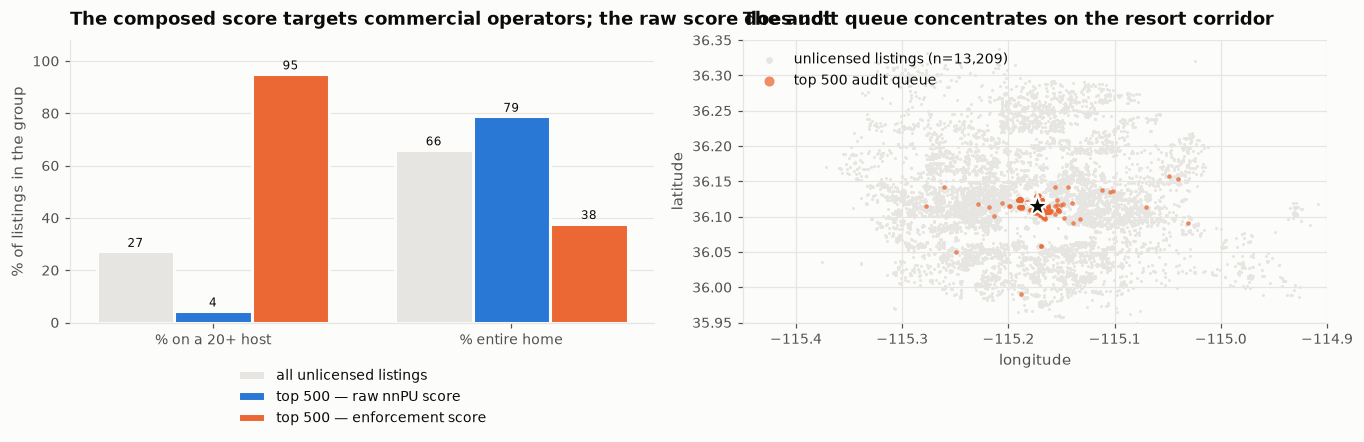

In [48]:
# Does the enforcement score select the population it is supposed to? Same profile
# comparison as section 8.5, now for the composed score.
top500_enf = feat[no_license].nlargest(500, "enforcement_priority")
pop_nl     = feat[no_license]

def profile_of(frame):
    return pd.Series({
        "median host portfolio size": frame["calculated_host_listings_count"].median(),
        "% on a 20+ host":            frame["is_large_host"].mean() * 100,
        "% entire home":              (frame["room_type"] == "Entire home/apt").mean() * 100,
        "median availability (days)": frame["availability_365"].median(),
        "median reviews/month":       frame["reviews_per_month"].median(),
        "median km to the Strip":     frame["distance_to_strip"].median(),
    })

compare = pd.DataFrame({
    "top 500 — enforcement score": profile_of(top500_enf),
    "top 500 — raw nnPU score":    profile_of(feat[no_license].nlargest(500, "nnpu_score")),
    "all unlicensed listings":     profile_of(pop_nl),
}).round(2)
print(compare.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# ── Left: the two rankings select opposite populations ──────────────────────
metrics = ["% on a 20+ host", "% entire home"]
x = np.arange(len(metrics)); w = 0.26
for i, (col, colr) in enumerate([("all unlicensed listings", GRID),
                                 ("top 500 — raw nnPU score", CAT["blue"]),
                                 ("top 500 — enforcement score", CAT["orange"])]):
    axes[0].bar(x + (i - 1) * w, compare.loc[metrics, col].values, w, label=col,
                color=colr, edgecolor=SURFACE, linewidth=2)
    for xi, v in zip(x + (i - 1) * w, compare.loc[metrics, col].values):
        axes[0].annotate(f"{v:.0f}", xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                         ha="center", fontsize=8, color=INK)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 108)
style_ax(axes[0], "The composed score targets commercial operators; the raw score does not",
         None, "% of listings in the group")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)

# ── Right: where the priority queue is on the map ───────────────────────────
axes[1].scatter(pop_nl["longitude"], pop_nl["latitude"], s=4, c=GRID, linewidths=0,
                label=f"unlicensed listings (n={len(pop_nl):,})")
axes[1].scatter(top500_enf["longitude"], top500_enf["latitude"], s=9, c=CAT["orange"],
                alpha=0.75, linewidths=0, label="top 500 audit queue")
axes[1].scatter([STRIP_LON], [STRIP_LAT], marker="*", s=240, c=INK,
                edgecolors=SURFACE, linewidths=1.5, zorder=5)
axes[1].set_xlim(-115.45, -114.90); axes[1].set_ylim(35.95, 36.35)
style_ax(axes[1], "The audit queue concentrates on the resort corridor",
         "longitude", "latitude", xgrid=True)
axes[1].legend(loc="upper left", markerscale=2.2)

plt.tight_layout(); plt.show()

In [49]:
# ── Deliverable: the ranked audit queue as a CSV an enforcement office can open ──
OUTPUT_COLS = {
    "id":                             "listing_id",
    "name":                           "listing_title",
    "host_id":                        "host_id",
    "neighbourhood":                  "jurisdiction",
    "room_type":                      "room_type",
    "latitude":                       "latitude",
    "longitude":                      "longitude",
    "calculated_host_listings_count": "host_portfolio_size",
    "minimum_nights":                 "minimum_nights",
    "availability_365":               "availability_365",
    "reviews_per_month":              "reviews_per_month",
    "number_of_reviews_ltm":          "reviews_last_12m",
    "distance_to_strip":              "km_to_strip",
    "license":                        "license_field",
    "commercial_pct":                 "commercial_evidence_pctile",
    "nnpu_score":                     "residential_permit_similarity",
    "enforcement_priority":           "priority_score",
}

queue = (feat[no_license | claims_exempt]
         .sort_values("enforcement_priority", ascending=False)
         .loc[:, list(OUTPUT_COLS)]
         .rename(columns=OUTPUT_COLS))
queue.insert(0, "rank", np.arange(1, len(queue) + 1))
queue.insert(1, "queue", np.where(queue["license_field"].isna(),
                                  "A_no_license", "B_claims_exempt"))
queue["review_status"] = "PENDING_HUMAN_REVIEW"      # nothing leaves this notebook pre-judged
queue = queue.round(4)

out_path = ARTIFACTS / "enforcement_audit_queue.csv"
queue.to_csv(out_path, index=False)
print(f"Wrote {len(queue):,} rows to {out_path}\n")
print(queue.head(10).to_string(index=False))
print(f"\nQueue composition: {(queue['queue'] == 'A_no_license').sum():,} with no license, "
      f"{(queue['queue'] == 'B_claims_exempt').sum():,} claiming exempt.")

Wrote 19,218 rows to artifacts/enforcement_audit_queue.csv

 rank           queue          listing_id                                      listing_title     host_id         jurisdiction       room_type  latitude  longitude  host_portfolio_size  minimum_nights  availability_365  reviews_per_month  reviews_last_12m  km_to_strip license_field  commercial_evidence_pctile  residential_permit_similarity  priority_score        review_status
    1 B_claims_exempt  960006121953179061       King Bed+Priv. Bath 3 mins to Airport RELAX! 452050358.0 Unincorporated Areas    Private room   36.0921  -115.1387                  2.0             1.0                 0              13.23               177       3.9603        Exempt                      1.0000                         0.0000          0.9999 PENDING_HUMAN_REVIEW
    2 B_claims_exempt  967957503938701124   King Bed Shared Bathroom 3 min to Airport RELAX! 452050358.0 Unincorporated Areas    Private room   36.0934  -115.1385                  2.0 

## 9.2 What was built, and what it is worth

**Results summary**

| Model | Test PU-AUC | P@100 | Notes |
|---|---|---|---|
| nnPU multimodal (tuned) | see §8.1 | see §8.1 | Text + entity + numeric, nnPU loss, 30 Optuna trials |
| LightGBM (tabular only) | see §8.1 | see §8.1 | Same budget; quantifies the text branch's lift |
| Autoencoder (anomaly) | see §8.1 | see §8.1 | Near-random — anomaly ≠ commercial |

**The four findings that matter most**

1. **The licensing rate falls with host size** — 4.6% for single-property hosts against 1.1% for
   20+ operators, who instead route through `"Exempt"` at 47%. The compliance problem is
   concentrated in exactly the population least likely to appear licensed.
2. **Consequently, "similarity to a licensed listing" is the wrong ranking target**, and a notebook
   that stopped at the nnPU score would have shipped an audit queue pointed at spare-bedroom hosts.
   §9 composes the model's output with explicit behavioral evidence to fix this.
3. **nnPU's clamp is doing real work.** The synthetic experiment in §5.3 shows uPU driving empirical
   risk negative and collapsing onto the revealed positives while nnPU recovers the hidden ones.
4. **Anomaly detection is the wrong tool for this shape of problem.** In a market where commercial
   operation is the norm, "unusual" and "commercial" point in different directions.
5. **The text branch does not pay for itself — and the ablation is what proved it.** Removing it
   *improves* test AUC and collapses the seed-to-seed spread (§8.3). Listing titles turn out to
   carry almost nothing about licensure; what they mostly contribute is 384 noisy dimensions.
   Building the multimodal model was still the right call — that conclusion is a *result*, not an
   assumption, and it only exists because the branch was built and then ablated honestly.
6. **A gradient-boosted tree is the right production choice here.** LightGBM on tabular features
   alone matches or beats the network (§8.1) at a fraction of the size, trains in seconds, is
   inspectable feature-by-feature, and is far easier to defend on appeal. The neural model earns
   its place as the *analysis* artifact: it is what makes the nnPU treatment of the unlabeled pool
   possible, and what the §8.2 independent-licensee check validates. If a county IT department has
   to maintain exactly one model, hand them the tree.

## 9.3 Limitations

**On the data**

- One snapshot, no time dimension. A listing that switched to a 31-night minimum the week the rules
  changed is indistinguishable here from one that always had it — and that transition is one of the
  strongest evasion signals available. Longitudinal snapshots would be the single highest-value
  addition.
- `license` reflects what Airbnb displays, not the county register. A licensed host who left the
  field blank is a false positive in every queue this notebook produces. **Reconciliation against
  the actual county register must precede any enforcement action.**
- `calculated_host_listings_count` counts one Airbnb account. Operators who split a portfolio across
  accounts or list on Vrbo are systematically under-counted — meaning the most sophisticated
  operators are the ones most likely to be missed. This model is best at catching operators who are
  not trying to hide.
- 14.6% of prices are missing and are not imputed. The flag handles it, but price-derived features
  are weaker than they appear.

**On the method**

- $\pi$ is assumed, not measured (§3.4). The ranking is robust to it (§5.7); the probabilities are
  not.
- The SCAR assumption behind PU learning almost certainly fails here: hosts who register are not a
  random sample of commercial operators — they are the compliance-minded ones. Real PU theory would
  call for a positive-propensity model, which this data cannot support.
- Host leakage inflates the stratified-split AUC; §8.4 quantifies the gap and the host-grouped
  number is the one to quote.
- The commercial-evidence weights in §9.1 are a policy judgement, not a fitted result. That is
  intentional — they should be argued over and revised by the people accountable for the decision.

## 9.4 Ethics and deployment controls

The output of this notebook is a **queue**, and a queue is an allocation of scrutiny. That has
consequences even when no penalty follows, so the following are requirements rather than
suggestions:

1. **No automated action, ever.** The score selects what a human examines. It never determines an
   outcome. Every exported row ships with `review_status = PENDING_HUMAN_REVIEW`, and the field
   exists to make automation an affirmative act someone has to take responsibility for.
2. **Register reconciliation first.** Before any listing is contacted, its license status must be
   verified against the county register. A large fraction of the "no license" queue will simply be
   recording gaps.
3. **Queue A and Queue B stay separate.** "You appear unregistered" and "your exemption claim
   warrants review" are different administrative acts with different burdens. Merging them would
   subject genuinely exempt hosts — including bona-fide long-term landlords — to the wrong process.
4. **Audit the queue for disparate impact before using it.** Every feature here is behavioral, but
   behavioral features carry geography, and geography carries demography. Concretely: compare the
   queue's neighbourhood distribution against the unlicensed population's, and investigate any
   jurisdiction that is over-represented. The §9.1 map exists partly so this is visible rather than
   buried. A score that concentrates on one area is not automatically wrong, but it must be
   explainable by operator behavior and not by who lives there.
5. **Publish the rubric.** The §9.1 weights and the feature list should be public. A host who lands
   in the queue is entitled to know which observable behaviors put them there. This is also what
   makes the score defensible on appeal.
6. **Measure and feed back.** Log the disposition of every audited listing. That converts this from
   a one-shot model into a system that can be evaluated on precision that is actually observed — and
   over time, those dispositions are the labelled negatives whose absence forced PU learning in the
   first place.
7. **Retire the score if it stops earning its place.** If audited precision falls to the base rate,
   the queue is adding process without adding accuracy, and it should be switched off rather than
   retuned indefinitely.

---

### Final caveat, restated because it is the most important sentence in this notebook

**Every score here measures behavioral similarity to a commercial operation. None of them measures
compliance with the law.** A high-priority listing is a listing worth a human look. It is not an
allegation, a finding, or evidence of one.